# SIADS Milestone 1 - Exploring the Relationship between Climate Change and Global Mortality

## Library Imports

**Environment Setup & Dependencies**

This notebook requires the following packages for climate-mortality analysis:

| Package | Min Version | Purpose |
|---------|-------------|---------|
| pandas | ≥ 1.3.0 | Data manipulation and merging |
| numpy | ≥ 1.21.0 | Numerical operations |
| matplotlib | ≥ 3.4.0 | Basic plotting |
| seaborn | ≥ 0.11.0 | Statistical visualizations |
| plotly | ≥ 5.0.0 | Interactive maps and widgets |
| scipy | ≥ 1.7.0 | Statistical analysis |
| ipywidgets | ≥ 7.6.0 | Interactive controls |

Quick Installation:

    pip install pandas numpy matplotlib seaborn plotly scipy ipywidgets

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
from scipy.stats import pearsonr

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import ipywidgets as widgets
from IPython.display import display, clear_output

pd.set_option("display.precision", 3)

In [73]:
# Suppress the DtypeWarnings
warnings.filterwarnings("ignore", category=pd.errors.DtypeWarning)

In [74]:
# Uncomment this cell for compatibility with google drive and colab

# from google.colab import drive
# from google.colab import output
# output.enable_custom_widget_manager()
# drive.mount('/content/drive')   # allows acces to Google Drive folder containing all datasets

## Data Ingestion and Processing

### Climate Dataset

The following data ingestion and processing procedures were implemented to obtain the Climate Dataset:

1. The raw temperature (**temperature_df**) , maximum temperature (**temperature_max_df**), precipitation (**precipitation_df**) and population (**wbo_pop_df**) datasets were read in.
2. The three climate datasets were cleaned, re-structured and combined.
3. Additional climate metrics were derived from the original climate variables (namely: historical baselines and differentials of original data and the baselines).
4. A period filter is applied for the relevant time period (1999 - 2019)
5. Cleaning, re-stucturing and merging of the population dataset.
6. Validation and missing or duplicate values checks are applied to ensure data integrity of the final dataset (**climate_df**).

In [75]:
data_path = 'Data/WBO Climate Data/'

# Uncomment for data path in google drive
# data_path = '/content/drive/My Drive/Colab Notebooks/MADS/SIADS 593/Data/WBO Climate Data/'

In [76]:
temperature_df = pd.read_csv(data_path + "temperature_means_cru_timeseries.csv")
temperature_max_df = pd.read_csv(data_path + "temperature_mean_max_cru_timeseries.csv")
precipitation_df = pd.read_csv(data_path + "precipitation_cru_timeseries.csv")
wbo_pop_df = pd.read_csv(data_path + "wbo_pop.csv")

temperature_df.head()
# temperature_max_df.head()
# precipitation_df.head()
# wbo_pop_df.head()


,code,name,1901-07,1902-07,1903-07,1904-07,1905-07,1906-07,1907-07,1908-07,...,2014-07,2015-07,2016-07,2017-07,2018-07,2019-07,2020-07,2021-07,2022-07,2023-07
0,ABW,Aruba (Neth.),28.22,27.79,27.89,27.62,27.68,27.58,27.56,27.46,...,29.46,29.68,29.71,29.27,28.95,29.33,29.34,29.04,28.81,29.39
1,AFG,Afghanistan,12.79,13.00,11.82,12.14,12.03,12.52,11.90,12.22,...,13.20,13.78,14.26,13.88,14.18,13.80,13.19,14.34,14.51,14.67
2,AGO,Angola,21.32,21.36,21.37,21.28,21.32,21.20,21.22,21.29,...,21.56,21.69,21.94,21.84,21.66,21.76,21.72,21.73,21.62,21.51
3,AIA,Anguilla (U.K.),27.19,26.77,26.81,26.34,26.69,26.45,26.11,26.25,...,27.97,28.22,28.15,27.96,27.70,28.08,28.04,27.96,27.73,28.35
4,ALA,Finland,5.39,3.43,5.29,4.72,5.17,5.70,4.55,4.88,...,7.22,6.88,6.35,6.17,6.94,6.92,7.82,6.21,6.87,6.66


In [77]:
dataframes = {
    "Temperature": temperature_df,
    "Max_Temperature": temperature_max_df,
    "Precipitation": precipitation_df,
}

# Clean column names and melt all dataframes
melted_dfs = []
for value_name, df in dataframes.items():
    df.columns = [col.replace("-07", "") if "-07" in col else col for col in df.columns]
    melted_df = df.melt(
        id_vars=["code", "name"], var_name="year", value_name=value_name
    )
    melted_dfs.append(melted_df)

# Merge all dataframes at once
climate_df = melted_dfs[0]
for df in melted_dfs[1:]:
    climate_df = pd.merge(climate_df, df, on=["code", "name", "year"])

climate_df["year"] = climate_df["year"].astype(int)
climate_df.head()

,code,name,year,Temperature,Max_Temperature,Precipitation
0,ABW,Aruba (Neth.),1901,28.22,31.78,420.90
1,AFG,Afghanistan,1901,12.79,20.24,295.12
2,AGO,Angola,1901,21.32,28.17,1021.01
3,AIA,Anguilla (U.K.),1901,27.19,30.17,1228.00
4,ALA,Finland,1901,5.39,8.68,364.30


#### Calculation and Addition of Climate Metrics

In [78]:
# Calculate base means and difference between actual and base mean for climate data
def base_average(
    climate_df,
    base_years=[1950, 1980],
    cols=["Temperature", "Max_Temperature", "Precipitation"],
):
    """
    Creates columns for means for indicated base years interval and
    columns for differences between actual and base mean.

    Parameters:
    -----------
    climate_df : pandas.DataFrame
        Climate DataFrame
    base_years : list(int, int)
        Year interval to calculate mean from
    cols : list(str,...)
        List of column names to calculate mean from

    Returns:
    --------
    pandas.DataFrame
        Original DataFrame with new columns joined on country
    """
    df = climate_df[
        (climate_df["year"] >= base_years[0]) & (climate_df["year"] <= base_years[1])
    ]

    for col in cols:
        missing_temp_names = df[df[col].isnull()]["name"].unique()
        if len(missing_temp_names) > 0:
            print("Countries with missing", col, "in base period:", missing_temp_names)

    bases = []
    for col in cols:
        bases.append(
            df.groupby("code", dropna=False)[col]
            .mean()
            .reset_index()
            .rename(columns={col: "base_" + col})
        )

    for base in bases:
        climate_df = climate_df.merge(base, on="code", how="left")

    for col in cols:
        climate_df["diff_" + col] = climate_df[col] - climate_df["base_" + col]

    return climate_df


In [79]:
# Invoke base_average function to calculate base means and differences
climate_df = base_average(
    climate_df,
    base_years=[1950, 1980],
    cols=["Temperature", "Max_Temperature", "Precipitation"],
)

# Filter climate_df for relevant years (1999-2019)
climate_df = climate_df[(climate_df["year"] >= 1999) & (climate_df["year"] <= 2019)]

climate_df.head()


Countries with missing Temperature in base period: ['Saint-Barthélemy (Fr.)' 'Bouvet Island (Nor.)']
Countries with missing Max_Temperature in base period: ['Saint-Barthélemy (Fr.)' 'Bouvet Island (Nor.)']
Countries with missing Precipitation in base period: ['Saint-Barthélemy (Fr.)' 'Bouvet Island (Nor.)']


,code,name,year,Temperature,Max_Temperature,Precipitation,base_Temperature,base_Max_Temperature,base_Precipitation,diff_Temperature,diff_Max_Temperature,diff_Precipitation
24108,ABW,Aruba (Neth.),1999,28.85,32.19,717.20,28.368,32.076,415.510,0.482,0.114,301.690
24109,AFG,Afghanistan,1999,13.82,21.12,317.20,12.412,19.874,335.424,1.408,1.246,-18.224
24110,AGO,Angola,1999,21.59,28.44,1057.47,21.352,28.179,1084.810,0.238,0.261,-27.340
24111,AIA,Anguilla (U.K.),1999,27.79,30.63,1131.50,26.862,29.793,1008.903,0.928,0.837,122.597
24112,ALA,Finland,1999,6.51,9.64,532.15,5.098,8.154,508.042,1.412,1.486,24.108


#### Population Dataset Incorporation

In [80]:
# Clean wbo_pop_df into mergable format.

# Clean column names to clarify years
wbo_pop_df.columns = [
    col.replace(col[5:], "") if "[YR" in col else col for col in wbo_pop_df.columns
]

# Drop unused columns and tail-rows
wbo_pop_df = wbo_pop_df.iloc[:-5].drop(["Series Name", "Series Code"], axis=1)
wbo_pop_df.rename(
    columns={"Country Name": "name", "Country Code": "code"}, inplace=True
)

# Melt the dataframe to get years as values
pop_melt = wbo_pop_df.melt(
    id_vars=["code", "name"], var_name="year", value_name="Total_Population"
)

pop_melt["year"] = pop_melt["year"].astype(int)

pop_melt.head()

,code,name,year,Total_Population
0,AFG,Afghanistan,1989,11874088
1,ALB,Albania,1989,3227943
2,DZA,Algeria,1989,24754485
3,ASM,American Samoa,1989,45191
4,AND,Andorra,1989,50620


In [81]:
# Merge population dataframe into climate_df on columns 'code' and 'year'
# 'code' is equivalent in both dataframes, 'name' is not
climate_df = pd.merge(climate_df, pop_melt, on=["code", "year"]).drop("name_y", axis=1)
climate_df.rename(columns={"name_x": "name"}, inplace=True)
climate_df['Total_Population'] = climate_df['Total_Population'].astype(int)

In [82]:
climate_df.head()

# Option to save to CSV
# climate_df.to_csv(data_path + "climate_df.csv", index=False)

,code,name,year,Temperature,Max_Temperature,Precipitation,base_Temperature,base_Max_Temperature,base_Precipitation,diff_Temperature,diff_Max_Temperature,diff_Precipitation,Total_Population
0,ABW,Aruba (Neth.),1999,28.85,32.19,717.20,28.368,32.076,415.510,0.482,0.114,301.690,89659
1,AFG,Afghanistan,1999,13.82,21.12,317.20,12.412,19.874,335.424,1.408,1.246,-18.224,19887785
2,AGO,Angola,1999,21.59,28.44,1057.47,21.352,28.179,1084.810,0.238,0.261,-27.340,15667235
3,ALB,Albania,1999,12.51,17.64,1193.17,11.665,16.906,1204.925,0.845,0.734,-11.755,3108778
4,AND,Andorra,1999,8.23,12.95,1104.75,7.063,11.684,1135.187,1.167,1.266,-30.437,65710


#### Final Climate DataFrame

In [83]:
# Check: duplicate country-year entires

duplicates = climate_df.duplicated(subset=["name", "year"]).sum()
print(f"Number of duplicated country-year combinations: {duplicates}")

# Show the duplicated rows if any exist
if duplicates > 0:
    duplicate_rows = climate_df[
        climate_df.duplicated(subset=["name", "year"], keep=False)
    ]
    print("Duplicated rows:")
    print(duplicate_rows.sort_values(["name", "year"]))

Number of duplicated country-year combinations: 0


In [84]:
# There exists dupliacte country name-year combinations due to country territoriees not being individually named

# Create comprehensive territory mapping
territory_map = {
    # France and territories
    "FRA": "France (Metropolitan)",
    "GLP": "France (Guadeloupe)",
    "GUF": "France (French Guiana)",
    "MTQ": "France (Martinique)",
    "MYT": "France (Mayotte)",
    "REU": "France (Réunion)",

    # China and territories
    "CHN": "China (Mainland)",
    "TWN": "China (Taiwan)",

    # Finland and territories
    "FIN": "Finland (Mainland)",
    "ALA": "Finland (Åland Islands)",
}

# Update the existing name column directly for all territories
for code_val, proper_name in territory_map.items():
    # Get the base country name (everything before the first parenthesis)
    base_country = proper_name.split(" (")[0]

    mask = (climate_df["name"] == base_country) & (climate_df["code"] == code_val)
    climate_df.loc[mask, "name"] = proper_name

# Check if we fixed all duplicates
print(f"\nChecking for remaining duplicates:")
duplicate_check = climate_df.groupby(["name", "year"]).size().reset_index(name="count")
remaining_duplicates = duplicate_check[duplicate_check["count"] > 1]
print(f"Remaining duplicate country-year combinations: {len(remaining_duplicates)}")


Checking for remaining duplicates:
Remaining duplicate country-year combinations: 0


In [85]:
climate_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4515 entries, 0 to 4514
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   code                  4515 non-null   object 
 1   name                  4515 non-null   object 
 2   year                  4515 non-null   int64  
 3   Temperature           4515 non-null   float64
 4   Max_Temperature       4515 non-null   float64
 5   Precipitation         4515 non-null   float64
 6   base_Temperature      4515 non-null   float64
 7   base_Max_Temperature  4515 non-null   float64
 8   base_Precipitation    4515 non-null   float64
 9   diff_Temperature      4515 non-null   float64
 10  diff_Max_Temperature  4515 non-null   float64
 11  diff_Precipitation    4515 non-null   float64
 12  Total_Population      4515 non-null   int64  
dtypes: float64(9), int64(2), object(2)
memory usage: 458.7+ KB


In [86]:
print("\nMissing Values:")
climate_df.isnull().sum()


Missing Values:


code                    0
name                    0
year                    0
Temperature             0
Max_Temperature         0
Precipitation           0
base_Temperature        0
base_Max_Temperature    0
base_Precipitation      0
diff_Temperature        0
diff_Max_Temperature    0
diff_Precipitation      0
Total_Population        0
dtype: int64

### Mortality Dataset

The following data ingestion and processing procedures were implemented to obtain the Mortality Dataset:
1. The raw mortality datasets (**Morticd10_part1 - Morticd10_part6**) were read in and combined.
2. The age and cause of death specific data is re-categorized for more meaningful analysis.
3. The mortality dataset is then aggregated and transformed to obtain unique country-year row format compatible with the climate dataset.
4. Country codes were mapped to readable country names by merging with a country reference dataset (**country_df**)
5. A period filter is applied for the relevant time period (1999 - 2019)
6. Validation and missing or duplicate values checks are applied to ensure data integrity of the final dataset (**mortality_df**).


In [87]:
data_path = 'Data/WHO Mortality/'

# Uncomment for data path in google drive
# data_path = '/content/drive/My Drive/Colab Notebooks/MADS/SIADS 593/Data/WHO Mortality/'


In [88]:
def combine_who_mortality_files(file_list, data_path):
    """
    Combines multiple WHO mortality data files into a single DataFrame.

    Parameters:
    -----------
    file_list : list
        List of filenames to combine
    data_path : str
        Path to the directory containing the files

    Returns:
    --------
    pandas.DataFrame
        Combined DataFrame with all data
    """

    # Initialize an empty list to store individual dataframes
    dataframes = []

    # Loop through each file and attempt to load it
    for filename in file_list:
        file_path = os.path.join(data_path, filename)

        # Check if file exists with exact name
        if os.path.exists(file_path):
            print(f"Loading {filename}...")
            df = pd.read_csv(file_path)
        else:
            # Try to find a case-insensitive match
            print(
                f"File not found at {file_path}, looking for case-insensitive match..."
            )
            found = False

            for existing_file in os.listdir(data_path):
                if filename.lower() in existing_file.lower():
                    correct_path = os.path.join(data_path, existing_file)
                    print(f"Found matching file: {existing_file}")
                    df = pd.read_csv(correct_path)
                    found = True
                    break

            if not found:
                print(
                    f"Warning: Could not find any file matching '{filename}'. Skipping."
                )
                continue

        print(f"Successfully loaded with shape: {df.shape}")
        dataframes.append(df)

    # If no dataframes were loaded, return None
    if not dataframes:
        print("No valid files were found. Returning None.")
        return None

    # Check if all dataframes have the same columns
    first_columns = dataframes[0].columns.tolist()
    all_same_columns = all(df.columns.tolist() == first_columns for df in dataframes)

    if not all_same_columns:
        print("Warning: Not all datasets have identical column structures")
        for i, df in enumerate(dataframes):
            diff_cols = set(df.columns) - set(first_columns)
            if diff_cols:
                print(f"File {i + 1} has different columns: {diff_cols}")
    else:
        print("All datasets have identical column structures - good to combine")

    # Combine the datasets
    combined_df = pd.concat(dataframes, ignore_index=True)
    print(f"Combined dataset shape: {combined_df.shape}")

    # Check for duplicates after combining
    duplicate_count = combined_df.duplicated().sum()
    print(f"Number of duplicate rows: {duplicate_count}")

    if duplicate_count > 0:
        print("Removing duplicates...")
        combined_df = combined_df.drop_duplicates()
        print(f"Shape after removing duplicates: {combined_df.shape}")

    # Display information about the combined dataset
    print("\nCombined WHO mortality dataset information:")
    print(
        f"Years covered: {sorted([int(year) for year in combined_df['Year'].unique() if not pd.isna(year)])}"
    )
    print(f"Number of countries: {combined_df['Country'].nunique()}")
    print(f"Total death records: {combined_df.shape[0]}")

    return combined_df


who_files = [
    "Morticd10_part1",
    "Morticd10_part2",
    "Morticd10_part3",
    "Morticd10_part4",
    "Morticd10_part5",
    "Morticd10_part6",
]
who_df = combine_who_mortality_files(who_files, data_path)
who_df = who_df.rename(columns={"country": "Code"})

# Option to save to CSV
# who_df.to_csv(data_path + 'who_mortality_raw.csv', index=False)

File not found at Data/WHO Mortality/Morticd10_part1, looking for case-insensitive match...
Found matching file: Morticd10_part1.csv


Successfully loaded with shape: (1022017, 39)
Loading Morticd10_part2...
Successfully loaded with shape: (958647, 39)
Loading Morticd10_part3...
Successfully loaded with shape: (1045687, 39)
Loading Morticd10_part4...
Successfully loaded with shape: (885319, 39)
Loading Morticd10_part5...
Successfully loaded with shape: (863021, 39)
Loading Morticd10_part6...
Successfully loaded with shape: (369240, 39)
All datasets have identical column structures - good to combine
Combined dataset shape: (5143931, 39)
Number of duplicate rows: 0

Combined WHO mortality dataset information:
Years covered: [1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]
Number of countries: 146
Total death records: 5143931


In [89]:
who_df.head()

,Country,Admin1,SubDiv,Year,List,Cause,Sex,Frmat,IM_Frmat,Deaths1,...,Deaths21,Deaths22,Deaths23,Deaths24,Deaths25,Deaths26,IM_Deaths1,IM_Deaths2,IM_Deaths3,IM_Deaths4
0,1400,NaN,NaN,2001,101,1000,1,7,8,332,...,95.0,NaN,NaN,NaN,NaN,0.0,8.0,NaN,NaN,NaN
1,1400,NaN,NaN,2001,101,1000,2,7,8,222,...,112.0,NaN,NaN,NaN,NaN,0.0,11.0,NaN,NaN,NaN
2,1400,NaN,NaN,2001,101,1001,1,7,8,24,...,5.0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN
3,1400,NaN,NaN,2001,101,1001,2,7,8,14,...,6.0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN
4,1400,NaN,NaN,2001,101,1002,1,7,8,0,...,0.0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN


In [90]:
who_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5143931 entries, 0 to 5143930
Data columns (total 39 columns):
 #   Column      Dtype  
---  ------      -----  
 0   Country     int64  
 1   Admin1      float64
 2   SubDiv      object 
 3   Year        int64  
 4   List        object 
 5   Cause       object 
 6   Sex         int64  
 7   Frmat       int64  
 8   IM_Frmat    int64  
 9   Deaths1     int64  
 10  Deaths2     float64
 11  Deaths3     float64
 12  Deaths4     float64
 13  Deaths5     float64
 14  Deaths6     float64
 15  Deaths7     float64
 16  Deaths8     float64
 17  Deaths9     float64
 18  Deaths10    float64
 19  Deaths11    float64
 20  Deaths12    float64
 21  Deaths13    float64
 22  Deaths14    float64
 23  Deaths15    float64
 24  Deaths16    float64
 25  Deaths17    float64
 26  Deaths18    float64
 27  Deaths19    float64
 28  Deaths20    float64
 29  Deaths21    float64
 30  Deaths22    float64
 31  Deaths23    float64
 32  Deaths24    float64
 33  Deaths2

In [91]:
# Check - verify that this country year combination's data is not lost in processing steps
# Filter data for country 4008 and year 2019
filtered_data = who_df[(who_df["Country"] == 4008) & (who_df["Year"] == 2019)]

print("Data for Country 4008 in 2019:")
print("=" * 50)

# Filter for cause 1000 specifically
cause_1000_data = filtered_data[filtered_data["Cause"] == "1000"]

total_deaths_cause_1000 = cause_1000_data["Deaths1"].sum()
print(f"1. Total Deaths from Cause 1000: {total_deaths_cause_1000}")

print("\n2. Deaths from Cause 1000 by Sex:")
deaths_by_sex_cause_1000 = cause_1000_data.groupby("Sex")["Deaths1"].sum()
for sex_code, deaths in deaths_by_sex_cause_1000.items():
    sex_label = (
        "Male"
        if sex_code == 1
        else "Female"
        if sex_code == 2
        else f"Sex code {sex_code}"
    )
    print(f"   {sex_label}: {deaths}")

Data for Country 4008 in 2019:
1. Total Deaths from Cause 1000: 301

2. Deaths from Cause 1000 by Sex:
   Male: 160
   Female: 141


####Cause and Age Categorization

Cause of death and age are re-categorized for more meaningful analysis.
- Cause of death contains many hyper-specific categories that are beyond the scope of our analysis. We combine these categories together based on the documentation to form broader categories of causes and eliminate missing data from countries that report only broader categories.
- Ages are binned together to provide uniformity across reporting methods where some countries only report age groups and not individual ages.


In [92]:
# This cell remaps old/expanded "Cause" codes to new/aggregated "Cause" codes

# Dictionary to map cause codes to aggregated categories
cause_dict = {
    "1000": "1000",
    "1001": ["A", "B"],
    "1026": ["C", "D0", "D1", "D2", "D3", "D4"],
    "1048": ["D5", "D6", "D7", "D8", "D9"],
    "1051": "E",
    "1055": "F",
    "1058": "G",
    "1062": ["H0", "H1", "H2", "H3", "H4", "H5"],
    "1063": ["H6", "H7", "H8", "H9"],
    "1064": "I",
    "1072": "J",
    "1078": "K",
    "1082": "L",
    "1083": "M",
    "1084": "N",
    "1087": "O",
    "1092": "P",
    "1093": "Q",
    "1094": "R",
    "1095": ["S", "T", "V", "W", "X", "Y"],
}


# Mapping function to convert "Cause" codes to aggregated mortality codes
def get_cause_dict(cause_code):
    cause_code = str(cause_code).strip().upper()

    if cause_code.isdigit():
        new_code = cause_code
    elif cause_code == "AAA":
        new_code = "1000"
    elif cause_code[0] in ["H", "D"]:
        new_code = [key for key, val in cause_dict.items() if cause_code[:2] in val]
    else:
        new_code = [key for key, val in cause_dict.items() if cause_code[0] in val]

    if new_code == []:
        new_code = cause_code

    return new_code[0] if isinstance(new_code, list) else new_code


# Apply function to change old 'Cause' codes to new 'Cause' codes
who_df["Cause"] = who_df["Cause"].apply(get_cause_dict)

# Drop rows that don't align with new 'Cause' codes
who_df.drop(
    who_df[~who_df["Cause"].isin(list(cause_dict.keys()))].index, axis=0, inplace=True
)
who_df.reset_index(drop=True, inplace=True)

who_df.head()

,Country,Admin1,SubDiv,Year,List,Cause,Sex,Frmat,IM_Frmat,Deaths1,...,Deaths21,Deaths22,Deaths23,Deaths24,Deaths25,Deaths26,IM_Deaths1,IM_Deaths2,IM_Deaths3,IM_Deaths4
0,1400,NaN,NaN,2001,101,1000,1,7,8,332,...,95.0,NaN,NaN,NaN,NaN,0.0,8.0,NaN,NaN,NaN
1,1400,NaN,NaN,2001,101,1000,2,7,8,222,...,112.0,NaN,NaN,NaN,NaN,0.0,11.0,NaN,NaN,NaN
2,1400,NaN,NaN,2001,101,1001,1,7,8,24,...,5.0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN
3,1400,NaN,NaN,2001,101,1001,2,7,8,14,...,6.0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN
4,1400,NaN,NaN,2001,101,1026,1,7,8,60,...,16.0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN


In [93]:
who_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5117682 entries, 0 to 5117681
Data columns (total 39 columns):
 #   Column      Dtype  
---  ------      -----  
 0   Country     int64  
 1   Admin1      float64
 2   SubDiv      object 
 3   Year        int64  
 4   List        object 
 5   Cause       object 
 6   Sex         int64  
 7   Frmat       int64  
 8   IM_Frmat    int64  
 9   Deaths1     int64  
 10  Deaths2     float64
 11  Deaths3     float64
 12  Deaths4     float64
 13  Deaths5     float64
 14  Deaths6     float64
 15  Deaths7     float64
 16  Deaths8     float64
 17  Deaths9     float64
 18  Deaths10    float64
 19  Deaths11    float64
 20  Deaths12    float64
 21  Deaths13    float64
 22  Deaths14    float64
 23  Deaths15    float64
 24  Deaths16    float64
 25  Deaths17    float64
 26  Deaths18    float64
 27  Deaths19    float64
 28  Deaths20    float64
 29  Deaths21    float64
 30  Deaths22    float64
 31  Deaths23    float64
 32  Deaths24    float64
 33  Deaths2

In [94]:
who_df["Cause"].unique()

array(['1000', '1001', '1026', '1048', '1051', '1055', '1058', '1062',
       '1063', '1064', '1072', '1078', '1082', '1083', '1084', '1087',
       '1092', '1093', '1094', '1095'], dtype=object)

In [95]:
# This cell bins ages of death together

# List of desired bins
age_bins = [
    "All_Ages",
    "Ages_0",
    "Ages_1_4",
    "Ages_5_14",
    "Ages_15_24",
    "Ages_25_34",
    "Ages_35_44",
    "Ages_45_54",
    "Ages_55_64",
    "Ages_65_Plus",
]

# List of death columns
death_cols = list(who_df.columns[pd.Series(who_df.columns).str.startswith("Deaths")])

# Dictionary mapping of bins
dict = {
    age_bins[0]: [death_cols[0]],
    age_bins[1]: [death_cols[1]],
    age_bins[2]: death_cols[2:6],
    age_bins[3]: death_cols[6:8],
    age_bins[4]: death_cols[8:10],
    age_bins[5]: death_cols[10:12],
    age_bins[6]: death_cols[12:14],
    age_bins[7]: death_cols[14:16],
    age_bins[8]: death_cols[16:18],
    age_bins[9]: death_cols[18:20],
}

# Combine death cloumns into bins
for key, value in dict.items():
    if len(value) > 1:
        who_df[key] = who_df[value].sum(axis=1)
    else:
        who_df[key] = who_df[value]

# Drop unneeded Death and IM_Death columns
who_df.drop(columns=death_cols, inplace=True)
who_df.drop(
    columns=who_df.columns[pd.Series(who_df.columns).str.startswith("IM_Deaths")],
    inplace=True,
)


In [96]:
who_df.head()

,Country,Admin1,SubDiv,Year,List,Cause,Sex,Frmat,IM_Frmat,All_Ages,Ages_0,Ages_1_4,Ages_5_14,Ages_15_24,Ages_25_34,Ages_35_44,Ages_45_54,Ages_55_64,Ages_65_Plus
0,1400,NaN,NaN,2001,101,1000,1,7,8,332,8.0,2.0,1.0,9.0,21.0,36.0,39.0,53.0,68.0
1,1400,NaN,NaN,2001,101,1000,2,7,8,222,11.0,1.0,1.0,1.0,2.0,12.0,13.0,21.0,48.0
2,1400,NaN,NaN,2001,101,1001,1,7,8,24,0.0,0.0,0.0,1.0,3.0,7.0,2.0,3.0,3.0
3,1400,NaN,NaN,2001,101,1001,2,7,8,14,0.0,0.0,0.0,0.0,0.0,3.0,1.0,4.0,0.0
4,1400,NaN,NaN,2001,101,1026,1,7,8,60,0.0,0.0,0.0,0.0,0.0,2.0,10.0,14.0,18.0


In [97]:
who_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5117682 entries, 0 to 5117681
Data columns (total 19 columns):
 #   Column        Dtype  
---  ------        -----  
 0   Country       int64  
 1   Admin1        float64
 2   SubDiv        object 
 3   Year          int64  
 4   List          object 
 5   Cause         object 
 6   Sex           int64  
 7   Frmat         int64  
 8   IM_Frmat      int64  
 9   All_Ages      int64  
 10  Ages_0        float64
 11  Ages_1_4      float64
 12  Ages_5_14     float64
 13  Ages_15_24    float64
 14  Ages_25_34    float64
 15  Ages_35_44    float64
 16  Ages_45_54    float64
 17  Ages_55_64    float64
 18  Ages_65_Plus  float64
dtypes: float64(10), int64(6), object(3)
memory usage: 741.9+ MB


#### Aggregation and Transformation

The raw mortalit dataset is aggregated to create a unique country-year row format compatible with the climate dataset. This involved grouping deaths by country, year, sex, and cause, then creating separate breakdowns for sex-specific mortality, cause-specific mortality, and age-specific mortality.

In [98]:
# Check the unique values for Sex and Cause
print("Unique Sex values:", who_df["Sex"].unique())
print("Unique Cause values:", who_df["Cause"].unique())

# Aggregate by Country, Year, Sex, Cause and sum across age groups
base_agg = (
    who_df.groupby(["Country", "Year", "Sex", "Cause"])[age_bins].sum().reset_index()
)

# Create sex breakdowns
sex_breakdown = (
    base_agg[base_agg["Cause"] == "1000"]
    .groupby(["Country", "Year", "Sex"])["All_Ages"]
    .sum()
    .reset_index()
)
sex_pivot = sex_breakdown.pivot(
    index=["Country", "Year"], columns="Sex", values="All_Ages"
)
sex_pivot.columns = [f"Sex_{col}" for col in sex_pivot.columns]
sex_pivot = sex_pivot.fillna(0).reset_index()

# Create cause breakdowns
cause_breakdown = (
    base_agg.groupby(["Country", "Year", "Cause"])["All_Ages"].sum().reset_index()
)
cause_pivot = cause_breakdown.pivot(
    index=["Country", "Year"], columns="Cause", values="All_Ages"
)
cause_pivot.columns = [f"Cause_{col}" for col in cause_pivot.columns]
cause_pivot = cause_pivot.fillna(0).reset_index()

# Create total deaths and age breakdowns
age_total = (
    base_agg[base_agg["Cause"] == "1000"]
    .groupby(["Country", "Year"])[age_bins]
    .sum()
    .reset_index()
)

# Merge everything together
agg_who_df = age_total.merge(sex_pivot, on=["Country", "Year"], how="left")
agg_who_df = agg_who_df.merge(cause_pivot, on=["Country", "Year"], how="left")

agg_who_df.head()

Unique Sex values: [1 2 9]
Unique Cause values: ['1000' '1001' '1026' '1048' '1051' '1055' '1058' '1062' '1063' '1064'
 '1072' '1078' '1082' '1083' '1084' '1087' '1092' '1093' '1094' '1095']


,Country,Year,All_Ages,Ages_0,Ages_1_4,Ages_5_14,Ages_15_24,Ages_25_34,Ages_35_44,Ages_45_54,...,Cause_1072,Cause_1078,Cause_1082,Cause_1083,Cause_1084,Cause_1087,Cause_1092,Cause_1093,Cause_1094,Cause_1095
0,1030,2021,17591,942.0,241.0,187.0,486.0,1165.0,2019.0,2389.0,...,743.0,399.0,87.0,49.0,440.0,42.0,496.0,91.0,4856.0,1203.0
1,1060,2011,2521,232.0,33.0,30.0,87.0,129.0,174.0,251.0,...,233.0,91.0,9.0,2.0,40.0,5.0,141.0,34.0,267.0,289.0
2,1060,2012,2764,231.0,42.0,29.0,79.0,133.0,168.0,254.0,...,260.0,88.0,2.0,3.0,61.0,1.0,243.0,35.0,302.0,268.0
3,1125,2000,382138,45257.0,12791.0,9528.0,11977.0,10616.0,18897.0,39839.0,...,31427.0,30852.0,171.0,168.0,9997.0,492.0,5876.0,6218.0,81441.0,16709.0
4,1125,2001,406489,45934.0,12741.0,9597.0,12227.0,10689.0,19551.0,43500.0,...,29590.0,33460.0,162.0,185.0,12262.0,517.0,6191.0,6891.0,82527.0,17066.0


In [99]:
agg_who_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2706 entries, 0 to 2705
Data columns (total 35 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country       2706 non-null   int64  
 1   Year          2706 non-null   int64  
 2   All_Ages      2706 non-null   int64  
 3   Ages_0        2706 non-null   float64
 4   Ages_1_4      2706 non-null   float64
 5   Ages_5_14     2706 non-null   float64
 6   Ages_15_24    2706 non-null   float64
 7   Ages_25_34    2706 non-null   float64
 8   Ages_35_44    2706 non-null   float64
 9   Ages_45_54    2706 non-null   float64
 10  Ages_55_64    2706 non-null   float64
 11  Ages_65_Plus  2706 non-null   float64
 12  Sex_1         2706 non-null   float64
 13  Sex_2         2706 non-null   float64
 14  Sex_9         2706 non-null   float64
 15  Cause_1000    2706 non-null   float64
 16  Cause_1001    2706 non-null   float64
 17  Cause_1026    2706 non-null   float64
 18  Cause_1048    2706 non-null 

In [100]:
# Check: the length of the agg_who_df should be the number of unique country-year combinations in the who_df

# Check unique country-year combinations in the original dataset
unique_country_years = who_df[["Country", "Year"]].drop_duplicates()
expected_rows = len(unique_country_years)

print(f"Number of unique Country-Year combinations: {expected_rows}")
print(f"Number of unique countries: {who_df['Country'].nunique()}")
print(f"Number of unique years: {who_df['Year'].nunique()}")
print(f"Year range: {who_df['Year'].min()} to {who_df['Year'].max()}")

# Check if every country has data for every year
total_possible = who_df["Country"].nunique() * who_df["Year"].nunique()
print(f"\nTheoretical maximum combinations: {total_possible}")
print(f"Actual combinations: {expected_rows}")
print(f"Coverage: {expected_rows / total_possible:.2%}")

Number of unique Country-Year combinations: 2708
Number of unique countries: 146
Number of unique years: 36
Year range: 1988 to 2023

Theoretical maximum combinations: 5256
Actual combinations: 2708
Coverage: 51.52%


In [101]:
# Check - verify that this country year combination's data is not lost in processing steps
# Filter data for country 4008 and year 2019
filtered_data = agg_who_df[
    (agg_who_df["Country"] == 4008) & (agg_who_df["Year"] == 2019)
]
filtered_data.head()

print("Data for Country 4008 in 2019:")
print("=" * 50)

total_deaths_cause_1000 = filtered_data["Cause_1000"].iloc[0]
print(f"1. Total Deaths from Cause 1000: {total_deaths_cause_1000}")

total_deaths_all_ages = filtered_data["All_Ages"].iloc[0]
print(f"\n2. Total Deaths from All Ages: {total_deaths_all_ages}")

print("\n3. Deaths from Cause 1000 by Sex:")
print(f"   Male: {filtered_data['Sex_1'].iloc[0]}")
print(f"   Female: {filtered_data['Sex_2'].iloc[0]}")


Data for Country 4008 in 2019:
1. Total Deaths from Cause 1000: 301.0

2. Total Deaths from All Ages: 301

3. Deaths from Cause 1000 by Sex:
   Male: 160.0
   Female: 141.0


#### Country Dataset Incorporation

In [102]:
# Reference country dataset is used to decipher country codes with readable country names
country_df = pd.read_csv(data_path + "country_codes")
country_df = country_df.rename(columns={"country": "Code", "name": "Country"})
country_df.head()

,Code,Country
0,1010,Algeria
1,1020,Angola
2,1025,Benin
3,1030,Botswana
4,1035,Burkina Faso


In [103]:
country_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 227 entries, 0 to 226
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Code     227 non-null    int64 
 1   Country  227 non-null    object
dtypes: int64(1), object(1)
memory usage: 3.7+ KB


In [104]:
# Merge to add country names
country_who_df = agg_who_df.merge(
    country_df,
    left_on="Country",  # country code column in agg_who_df
    right_on="Code",  # country code column in country_df
    how="left",  # keep all rows from agg_who_df
)

# Drop the duplicate Code column since we already have Country (the numeric code)
country_who_df = country_who_df.drop("Code", axis=1)

# Rename the Country column from country_df to something clearer
country_who_df = country_who_df.rename(
    columns={"Country_y": "Country_Name", "Country_x": "Country_Code"}
)

# Re-order columns
cols = country_who_df.columns.tolist()
country_who_df = country_who_df[
    ["Country_Name"] + [col for col in cols if col != "Country_Name"]
]

# Check merge results
print(f"Rows before merge: {len(agg_who_df)}")
print(f"Rows after merge: {len(country_who_df)}")
print(f"Countries without names: {country_who_df['Country_Name'].isna().sum()}")

country_who_df.head()

Rows before merge: 2706
Rows after merge: 2706
Countries without names: 0


,Country_Name,Country_Code,Year,All_Ages,Ages_0,Ages_1_4,Ages_5_14,Ages_15_24,Ages_25_34,Ages_35_44,...,Cause_1072,Cause_1078,Cause_1082,Cause_1083,Cause_1084,Cause_1087,Cause_1092,Cause_1093,Cause_1094,Cause_1095
0,Botswana,1030,2021,17591,942.0,241.0,187.0,486.0,1165.0,2019.0,...,743.0,399.0,87.0,49.0,440.0,42.0,496.0,91.0,4856.0,1203.0
1,Cape Verde,1060,2011,2521,232.0,33.0,30.0,87.0,129.0,174.0,...,233.0,91.0,9.0,2.0,40.0,5.0,141.0,34.0,267.0,289.0
2,Cape Verde,1060,2012,2764,231.0,42.0,29.0,79.0,133.0,168.0,...,260.0,88.0,2.0,3.0,61.0,1.0,243.0,35.0,302.0,268.0
3,Egypt,1125,2000,382138,45257.0,12791.0,9528.0,11977.0,10616.0,18897.0,...,31427.0,30852.0,171.0,168.0,9997.0,492.0,5876.0,6218.0,81441.0,16709.0
4,Egypt,1125,2001,406489,45934.0,12741.0,9597.0,12227.0,10689.0,19551.0,...,29590.0,33460.0,162.0,185.0,12262.0,517.0,6191.0,6891.0,82527.0,17066.0


In [105]:
# Check: which countries have codes in the reference country_df but don't appear in the WHO mortality dataset to show gaps in data

# Get unique country codes from both datasets
who_countries = set(agg_who_df["Country"].unique())
available_countries = set(country_df["Code"].unique())

# Find countries in country_df but not in WHO data
missing_from_who = available_countries - who_countries

# Create DataFrame of missing countries
missing_countries_df = (
    country_df[country_df["Code"].isin(missing_from_who)][["Code", "Country"]]
    .sort_values("Country")
    .reset_index(drop=True)
)

print(f"Total countries in country_df: {len(available_countries)}")
print(f"Countries with WHO mortality data: {len(who_countries)}")
print(f"Countries missing from WHO data: {len(missing_from_who)}")

# Remove historical/former countries that overlap with current ones
problematic_countries = [
    "USSR, Former",
    "Germany, Former Democratic Republic",
    "Germany, West Berlin"
]

missing_countries_df = missing_countries_df[
    ~missing_countries_df["Country"].isin(problematic_countries)
]

# Display the DataFrame
missing_countries_df.head()

Total countries in country_df: 227
Countries with WHO mortality data: 146
Countries missing from WHO data: 81


,Code,Country
0,3010,Afghanistan
1,4005,Albania
2,1010,Algeria
3,1020,Angola
4,3025,Bangladesh


#### Final Mortality DataFrame

In [106]:
# The final mortality DataFrame comprises of all non-missing country-year combinations of
# age, sex and cause of death related mortality statistics for the filtered period of 1999-2019
mortality_df = country_who_df.sort_values("Country_Name").reset_index(drop=True)

# Filter dataset for only relevant years (1999-2019)
mortality_df_pre_filter = mortality_df
mortality_df = mortality_df[(mortality_df["Year"] >= 1999) & (mortality_df["Year"] <= 2019)]

mortality_df.head()

,Country_Name,Country_Code,Year,All_Ages,Ages_0,Ages_1_4,Ages_5_14,Ages_15_24,Ages_25_34,Ages_35_44,...,Cause_1072,Cause_1078,Cause_1082,Cause_1083,Cause_1084,Cause_1087,Cause_1092,Cause_1093,Cause_1094,Cause_1095
0,Andorra,4008,2019,301,0.0,0.0,0.0,0.0,0.0,0.0,...,35.0,17.0,0.0,0.0,6.0,0.0,1.0,1.0,14.0,16.0
1,Andorra,4008,2011,275,0.0,0.0,0.0,0.0,0.0,0.0,...,26.0,7.0,1.0,2.0,6.0,0.0,0.0,0.0,28.0,23.0
2,Andorra,4008,2012,303,0.0,0.0,0.0,0.0,0.0,0.0,...,24.0,14.0,0.0,1.0,11.0,0.0,3.0,2.0,23.0,16.0
3,Andorra,4008,2013,239,0.0,0.0,0.0,0.0,0.0,0.0,...,20.0,10.0,0.0,1.0,8.0,0.0,0.0,1.0,17.0,18.0
4,Andorra,4008,2014,276,0.0,0.0,0.0,0.0,0.0,0.0,...,28.0,8.0,0.0,0.0,3.0,0.0,2.0,1.0,28.0,14.0


In [107]:
mortality_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2294 entries, 0 to 2705
Data columns (total 36 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country_Name  2294 non-null   object 
 1   Country_Code  2294 non-null   int64  
 2   Year          2294 non-null   int64  
 3   All_Ages      2294 non-null   int64  
 4   Ages_0        2294 non-null   float64
 5   Ages_1_4      2294 non-null   float64
 6   Ages_5_14     2294 non-null   float64
 7   Ages_15_24    2294 non-null   float64
 8   Ages_25_34    2294 non-null   float64
 9   Ages_35_44    2294 non-null   float64
 10  Ages_45_54    2294 non-null   float64
 11  Ages_55_64    2294 non-null   float64
 12  Ages_65_Plus  2294 non-null   float64
 13  Sex_1         2294 non-null   float64
 14  Sex_2         2294 non-null   float64
 15  Sex_9         2294 non-null   float64
 16  Cause_1000    2294 non-null   float64
 17  Cause_1001    2294 non-null   float64
 18  Cause_1026    2294 non-null   flo

In [108]:
print("\nMissing Values:")
mortality_df.isnull().sum()


Missing Values:


Country_Name    0
Country_Code    0
Year            0
All_Ages        0
Ages_0          0
Ages_1_4        0
Ages_5_14       0
Ages_15_24      0
Ages_25_34      0
Ages_35_44      0
Ages_45_54      0
Ages_55_64      0
Ages_65_Plus    0
Sex_1           0
Sex_2           0
Sex_9           0
Cause_1000      0
Cause_1001      0
Cause_1026      0
Cause_1048      0
Cause_1051      0
Cause_1055      0
Cause_1058      0
Cause_1062      0
Cause_1063      0
Cause_1064      0
Cause_1072      0
Cause_1078      0
Cause_1082      0
Cause_1083      0
Cause_1084      0
Cause_1087      0
Cause_1092      0
Cause_1093      0
Cause_1094      0
Cause_1095      0
dtype: int64

In [109]:
# Check: duplicate country-year entires

duplicates = mortality_df.duplicated(subset=["Country_Name", "Year"]).sum()
print(f"Number of duplicated country-year combinations: {duplicates}")

# Show the duplicated rows if any exist
if duplicates > 0:
    duplicate_rows = mortality_df[
        mortality_df.duplicated(subset=["Country", "Year"], keep=False)
    ]
    print("Duplicated rows:")
    print(duplicate_rows.sort_values(["Country", "Year"]))

Number of duplicated country-year combinations: 0


### Combined Dataset
The following processing procedures were implemented to obtain the Combined Dataset:
1. Examination of existing countries in both datasets to determine overlap and manual country mapping for countries with differing names.
2. Dropping of all unmatched countries to ensure a complete dataset.
3. Merging of the climate and mortality datasets based on unique country-year combinations.
4. Calculation of the death rate, enabling population-adjusted mortality analysis.
5. Log transformation of specific variables (total population, cause of deaths, and ages of death), enabling more accurate and statistically sound comparison.

In [110]:
# Get unique countries from each dataset
mortality_countries = set(mortality_df["Country_Name"].unique())
climate_countries = set(climate_df["name"].unique())

print(f"Number of unique countries in mortality dataset: {len(mortality_countries)}")
print(f"Number of unique countries in climate dataset: {len(climate_countries)}")

# Find exact matches
exact_matches = mortality_countries.intersection(climate_countries)
print(f"\nNumber of exact matches: {len(exact_matches)}")
print(f"Exact matches: {sorted(exact_matches)}")

# Find countries only in mortality data
mortality_only = mortality_countries - climate_countries
print(f"\nCountries only in mortality dataset ({len(mortality_only)}):")
for country in sorted(mortality_only):
    print(f"  - {country}")

# Find countries only in climate data
climate_only = climate_countries - mortality_countries
print(f"\nCountries only in climate dataset ({len(climate_only)}):")
for country in sorted(climate_only):
    print(f"  - {country}")

# Summary statistics
total_unique = len(mortality_countries.union(climate_countries))
overlap_percentage = (len(exact_matches) / total_unique) * 100

print(f"\n--- Summary ---")
print(f"Total unique countries across both datasets: {total_unique}")
print(f"Exact matches: {len(exact_matches)} ({overlap_percentage:.1f}% of total)")
print(f"Countries needing attention: {len(mortality_only) + len(climate_only)}")

Number of unique countries in mortality dataset: 144
Number of unique countries in climate dataset: 215

Number of exact matches: 107
Exact matches: ['Andorra', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Australia', 'Austria', 'Azerbaijan', 'Bahrain', 'Barbados', 'Belarus', 'Belgium', 'Belize', 'Bolivia', 'Bosnia and Herzegovina', 'Brazil', 'Brunei Darussalam', 'Bulgaria', 'Canada', 'Chile', 'Colombia', 'Costa Rica', 'Croatia', 'Cuba', 'Cyprus', 'Czech Republic', 'Denmark', 'Dominica', 'Dominican Republic', 'Ecuador', 'El Salvador', 'Estonia', 'Fiji', 'Georgia', 'Germany', 'Greece', 'Grenada', 'Guatemala', 'Guyana', 'Haiti', 'Honduras', 'Hungary', 'Iceland', 'Iraq', 'Ireland', 'Israel', 'Italy', 'Jamaica', 'Japan', 'Jordan', 'Kazakhstan', 'Kiribati', 'Kuwait', 'Latvia', 'Lebanon', 'Lithuania', 'Luxembourg', 'Malaysia', 'Maldives', 'Malta', 'Mauritius', 'Mexico', 'Mongolia', 'Montenegro', 'Morocco', 'Netherlands', 'New Zealand', 'Nicaragua', 'North Macedonia', 'Norway', 'Oman', 'Pa

In [111]:
# Manual mapping from mortality dataset country names to climate dataset country names

mortality_to_climate_mapping = {
    # Clear matches with different naming conventions
    "Egypt": "Arab Republic of Egypt",
    "Iran (Islamic Republic of)": "Islamic Republic of Iran",
    "Turkey": "Türkiye",
    "Venezuela": "R. B. de Venezuela",
    "Slovakia": "Slovak Republic",
    "Republic of Moldova": "Moldova",
    "Kyrgyzstan": "Kyrgyz Republic",
    "Bahamas": "The Bahamas",
    "Cape Verde": "Cabo Verde",
    "Micronesia (Federated States of)": "Federated States of Micronesia",
    "Saint Vincent and Grenadines": "Saint Vincent and the Grenadines",

    # Territories with parenthetical notation in climate dataset
    "Anguilla": "Anguilla (U.K.)",
    "Aruba": "Aruba (Neth.)",
    "Bermuda": "Bermuda (U.K.)",
    "British Virgin Islands": "British Virgin Islands (U.K.)",
    "Cayman Islands": "Cayman Islands (U.K.)",
    "Hong Kong SAR": "Hong Kong, SAR",
    "Montserrat": "Montserrat (U.K.)",
    "Puerto Rico": "Puerto Rico (U.S.)",
    "Turks and Caicos Islands": "Turks and Caicos Islands (U.K.)",
    "Virgin Islands (USA)": "United States Virgin Islands (U.S.)",

    # Historical/political name changes
    "Libyan Arab Jamahiriya": "Libya",
    "Occupied Palestinian Territory": "West Bank and Gaza",
    "Saint Pierre and Miquelon": "Saint-Pierre-et-Miquelon (Fr.)",

    # Territories that should map to their updated names
    "France": "France (Metropolitan)",
    "Finland": "Finland (Mainland)",
    "French Guiana": "France (French Guiana)",
    "Guadeloupe": "France (Guadeloupe)",
    "Martinique": "France (Martinique)",
    "Mayotte": "France (Mayotte)",
    "Reunion": "France (Réunion)",
}

In [112]:
# Countries that can be mapped from mortality to climate
mappable_mortality_countries = set(mortality_to_climate_mapping.keys())
mapped_climate_countries = set(mortality_to_climate_mapping.values())

# Final list of countries that will have both mortality and climate data
countries_to_keep_mortality = exact_matches.union(mappable_mortality_countries)
countries_to_keep_climate = exact_matches.union(mapped_climate_countries)

print(f"Countries to keep in mortality dataset: {len(countries_to_keep_mortality)}")
print(f"Countries to keep in climate dataset: {len(countries_to_keep_climate)}")

# Filter both datasets to only include these countries
mortality_df_filtered = mortality_df[
    mortality_df["Country_Name"].isin(countries_to_keep_mortality)
].copy()
climate_df_filtered = climate_df[
    climate_df["name"].isin(countries_to_keep_climate)
].copy()

print(f"Original mortality dataset: {mortality_df.shape}")
print(f"Filtered mortality dataset: {mortality_df_filtered.shape}")
print(f"Original climate dataset: {climate_df.shape}")
print(f"Filtered climate dataset: {climate_df_filtered.shape}")

# Apply mapping to the filtered mortality dataset
mortality_df_filtered["Country_mapped"] = (
    mortality_df_filtered["Country_Name"]
    .map(mortality_to_climate_mapping)
    .fillna(mortality_df_filtered["Country_Name"])
)

# Merge the filtered datasets
merged_df = pd.merge(
    mortality_df_filtered,
    climate_df_filtered,
    left_on=["Country_mapped", "Year"],
    right_on=["name", "year"],
    how="inner",  # Inner join since both datasets only contain matching countries
)

print(f"Final merged dataset shape: {merged_df.shape}")
print(
    f"Number of unique countries in merged dataset: {merged_df['Country_mapped'].nunique()}"
)

# Drop the redundant columns from climate dataset after merge
merged_df = merged_df.drop(columns=["code", "name", "year", "Country_mapped"])

merged_df.head()

# Option to save to CSV
# merged_df.to_csv('/content/drive/My Drive/Colab Notebooks/MADS/SIADS 593/Data/merged_df.csv', index=False)

Countries to keep in mortality dataset: 138
Countries to keep in climate dataset: 138
Original mortality dataset: (2294, 36)
Filtered mortality dataset: (2217, 36)
Original climate dataset: (4515, 13)
Filtered climate dataset: (2730, 13)
Final merged dataset shape: (2086, 50)
Number of unique countries in merged dataset: 130


,Country_Name,Country_Code,Year,All_Ages,Ages_0,Ages_1_4,Ages_5_14,Ages_15_24,Ages_25_34,Ages_35_44,...,Temperature,Max_Temperature,Precipitation,base_Temperature,base_Max_Temperature,base_Precipitation,diff_Temperature,diff_Max_Temperature,diff_Precipitation,Total_Population
0,Andorra,4008,2019,301,0.0,0.0,0.0,0.0,0.0,0.0,...,8.98,14.23,1013.04,7.063,11.684,1135.187,1.917,2.546,-122.147,76474
1,Andorra,4008,2011,275,0.0,0.0,0.0,0.0,0.0,0.0,...,8.92,13.77,905.48,7.063,11.684,1135.187,1.857,2.086,-229.707,77783
2,Andorra,4008,2012,303,0.0,0.0,0.0,0.0,0.0,0.0,...,8.25,13.39,839.71,7.063,11.684,1135.187,1.187,1.706,-295.477,76834
3,Andorra,4008,2013,239,0.0,0.0,0.0,0.0,0.0,0.0,...,7.74,12.52,1164.35,7.063,11.684,1135.187,0.677,0.836,29.163,75194
4,Andorra,4008,2014,276,0.0,0.0,0.0,0.0,0.0,0.0,...,9.04,13.62,1214.01,7.063,11.684,1135.187,1.977,1.936,78.823,73737


#### Death Rate Calculation


In [113]:
# Calculate death rate or deaths per capita as population-adjusted total deaths
merged_df["Death_Rate"] = merged_df["All_Ages"] / merged_df["Total_Population"]
merged_df.head()

,Country_Name,Country_Code,Year,All_Ages,Ages_0,Ages_1_4,Ages_5_14,Ages_15_24,Ages_25_34,Ages_35_44,...,Max_Temperature,Precipitation,base_Temperature,base_Max_Temperature,base_Precipitation,diff_Temperature,diff_Max_Temperature,diff_Precipitation,Total_Population,Death_Rate
0,Andorra,4008,2019,301,0.0,0.0,0.0,0.0,0.0,0.0,...,14.23,1013.04,7.063,11.684,1135.187,1.917,2.546,-122.147,76474,0.004
1,Andorra,4008,2011,275,0.0,0.0,0.0,0.0,0.0,0.0,...,13.77,905.48,7.063,11.684,1135.187,1.857,2.086,-229.707,77783,0.004
2,Andorra,4008,2012,303,0.0,0.0,0.0,0.0,0.0,0.0,...,13.39,839.71,7.063,11.684,1135.187,1.187,1.706,-295.477,76834,0.004
3,Andorra,4008,2013,239,0.0,0.0,0.0,0.0,0.0,0.0,...,12.52,1164.35,7.063,11.684,1135.187,0.677,0.836,29.163,75194,0.003
4,Andorra,4008,2014,276,0.0,0.0,0.0,0.0,0.0,0.0,...,13.62,1214.01,7.063,11.684,1135.187,1.977,1.936,78.823,73737,0.004


In [114]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2086 entries, 0 to 2085
Data columns (total 47 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Country_Name          2086 non-null   object 
 1   Country_Code          2086 non-null   int64  
 2   Year                  2086 non-null   int64  
 3   All_Ages              2086 non-null   int64  
 4   Ages_0                2086 non-null   float64
 5   Ages_1_4              2086 non-null   float64
 6   Ages_5_14             2086 non-null   float64
 7   Ages_15_24            2086 non-null   float64
 8   Ages_25_34            2086 non-null   float64
 9   Ages_35_44            2086 non-null   float64
 10  Ages_45_54            2086 non-null   float64
 11  Ages_55_64            2086 non-null   float64
 12  Ages_65_Plus          2086 non-null   float64
 13  Sex_1                 2086 non-null   float64
 14  Sex_2                 2086 non-null   float64
 15  Sex_9                

In [115]:
print("\nMissing Values:")
merged_df.isnull().sum()


Missing Values:


Country_Name            0
Country_Code            0
Year                    0
All_Ages                0
Ages_0                  0
Ages_1_4                0
Ages_5_14               0
Ages_15_24              0
Ages_25_34              0
Ages_35_44              0
Ages_45_54              0
Ages_55_64              0
Ages_65_Plus            0
Sex_1                   0
Sex_2                   0
Sex_9                   0
Cause_1000              0
Cause_1001              0
Cause_1026              0
Cause_1048              0
Cause_1051              0
Cause_1055              0
Cause_1058              0
Cause_1062              0
Cause_1063              0
Cause_1064              0
Cause_1072              0
Cause_1078              0
Cause_1082              0
Cause_1083              0
Cause_1084              0
Cause_1087              0
Cause_1092              0
Cause_1093              0
Cause_1094              0
Cause_1095              0
Temperature             0
Max_Temperature         0
Precipitatio

In [116]:
# Check - verify that this country year combination's data is not lost in processing steps
# Filter data for country 4008 and year 2019
filtered_data = merged_df[
    (merged_df["Country_Code"] == 4008) & (merged_df["Year"] == 2019)
]
filtered_data.head()

print("Data for Country 4008 in 2019:")
print("=" * 50)

total_deaths_cause_1000 = filtered_data["Cause_1000"].iloc[0]
print(f"1. Total Deaths from Cause 1000: {total_deaths_cause_1000}")

total_deaths_all_ages = filtered_data["All_Ages"].iloc[0]
print(f"\n2. Total Deaths from All Ages: {total_deaths_all_ages}")

print("\n3. Deaths from Cause 1000 by Sex:")
print(f"   Male: {filtered_data['Sex_1'].iloc[0]}")
print(f"   Female: {filtered_data['Sex_2'].iloc[0]}")

Data for Country 4008 in 2019:
1. Total Deaths from Cause 1000: 301.0

2. Total Deaths from All Ages: 301

3. Deaths from Cause 1000 by Sex:
   Male: 160.0
   Female: 141.0


#### Log Transformation


In [117]:
# Log transformations are taken of the variables with heavy right-skew to allow for more accurate comparison.
# These transformations will help conform the variables to a more normal shape

# Add log-transformed columns for each age group, cause, population, and sex

# Identify relevant columns
age_cols = [col for col in merged_df.columns if col.startswith("Ages_") or col == "All_Ages"]
cause_cols = [col for col in merged_df.columns if col.startswith("Cause_")]
sex_cols = [col for col in merged_df.columns if col.startswith("Sex_")]
pop_cols = ["Total_Population"]

# Add log-transformed columns (use np.log1p to handle zeros)
for col in age_cols + cause_cols + sex_cols + pop_cols:
    if col in merged_df.columns:
        merged_df[f"log_{col}"] = np.log1p(merged_df[col])
merged_df.head()

,Country_Name,Country_Code,Year,All_Ages,Ages_0,Ages_1_4,Ages_5_14,Ages_15_24,Ages_25_34,Ages_35_44,...,log_Cause_1084,log_Cause_1087,log_Cause_1092,log_Cause_1093,log_Cause_1094,log_Cause_1095,log_Sex_1,log_Sex_2,log_Sex_9,log_Total_Population
0,Andorra,4008,2019,301,0.0,0.0,0.0,0.0,0.0,0.0,...,1.946,0.0,0.693,0.693,2.708,2.833,5.081,4.956,0.0,11.245
1,Andorra,4008,2011,275,0.0,0.0,0.0,0.0,0.0,0.0,...,1.946,0.0,0.000,0.000,3.367,3.178,5.056,4.787,0.0,11.262
2,Andorra,4008,2012,303,0.0,0.0,0.0,0.0,0.0,0.0,...,2.485,0.0,1.386,1.099,3.178,2.833,5.130,4.913,0.0,11.249
3,Andorra,4008,2013,239,0.0,0.0,0.0,0.0,0.0,0.0,...,2.197,0.0,0.000,0.693,2.890,2.944,4.890,4.682,0.0,11.228
4,Andorra,4008,2014,276,0.0,0.0,0.0,0.0,0.0,0.0,...,1.386,0.0,1.099,0.693,3.367,2.708,5.130,4.691,0.0,11.208


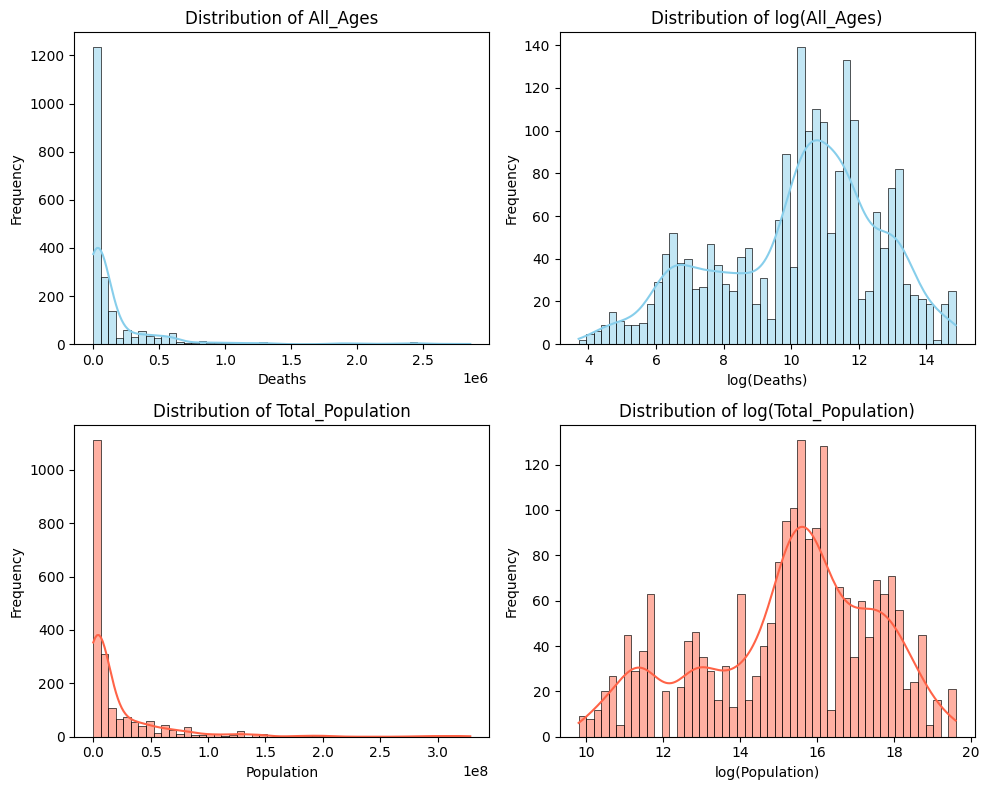

In [118]:
# Visualize the distributions of All_Ages and Total_Population (raw vs log-transformed)

plt.figure(figsize=(10, 8))

# All_Ages (raw)
plt.subplot(2, 2, 1)
sns.histplot(merged_df["All_Ages"].dropna(), bins=50, kde=True, color="skyblue")
plt.title("Distribution of All_Ages")
plt.xlabel("Deaths")
plt.ylabel("Frequency")

# All_Ages (log)
plt.subplot(2, 2, 2)
sns.histplot(merged_df["log_Cause_1000"].dropna(), bins=50, kde=True, color="skyblue")
plt.title("Distribution of log(All_Ages)")
plt.xlabel("log(Deaths)")
plt.ylabel("Frequency")

# Total_Population (raw)
plt.subplot(2, 2, 3)
sns.histplot(merged_df["Total_Population"].dropna(), bins=50, kde=True, color="tomato")
plt.title("Distribution of Total_Population")
plt.xlabel("Population")
plt.ylabel("Frequency")

# Total_Population (log)
plt.subplot(2, 2, 4)
sns.histplot(merged_df["log_Total_Population"].dropna(), bins=50, kde=True, color="tomato")
plt.title("Distribution of log(Total_Population)")
plt.xlabel("log(Population)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

## Data Visualisation and EDA

The exploratory analysis and visualisation is broken into the following parts:
1. Univariate Data Analysis: Looking at individual variables with respect to data coverage (both geographic and temporal) and well as distributions of these variables.
2. Bivariate Data Analysis: Examining relationships between pairs of variables to identify climate-mortality patterns. Key relationships explored include mortality demographics (cause, age, sex) versus death totals, climate variable interactions (temperature vs precipitation), temporal climate trends (mean temperature and differential temperature over time), climate metrics versus total deaths, and mortality patterns across climate categorizations (temperature/precipitation bins).
3. Multivariate Analysis: Examining complex relationships across multiple variables simultaneously. Analysis includes a correlation matrix of key climate and mortality variables to identify strongest associations, dynamic interactive plots enabling global trend analysis (with aggregated data) and country-specific comparisons (raw data) across multiple variables, and interactive geographic visualizations displaying precipitation, temperature, total deaths, and death rates on world maps with year-by-year progression capabilities.
4. Correlation Analyses: Age and cause-specific correlation analyses were conducted to determine definitive relationships between climate variables and mortality across demographic and disease categories, revealing vulnerability patterns by age group and cause of death.

### Univariate Data Analysis

In [119]:
# Statistical overview of variables
merged_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Country_Code,2086.0,3200.134,996.032,1060.000,2260.000,3255.000,4184.000,5.198e+03
Year,2086.0,2009.336,5.871,1999.000,2004.000,2009.000,2014.000,2.019e+03
All_Ages,2086.0,177249.471,387037.983,40.000,5437.500,40677.000,131982.000,2.855e+06
Ages_0,2086.0,3574.007,9525.185,0.000,110.250,457.000,2469.000,1.376e+05
Ages_1_4,2086.0,872.130,2268.952,0.000,24.250,90.000,514.000,2.409e+04
...,...,...,...,...,...,...,...,...
log_Cause_1095,2086.0,7.607,2.362,0.000,5.958,7.924,9.220,1.273e+01
log_Sex_1,2086.0,9.599,2.351,2.708,8.012,9.943,11.150,1.420e+01
log_Sex_2,2086.0,9.443,2.398,2.773,7.784,9.867,11.062,1.414e+01
log_Sex_9,2086.0,0.507,1.467,0.000,0.000,0.000,0.000,7.885e+00


The WHO mortality dataset documentation lists the broader categories of death causes as the following. These represent the categorization we previously preformed on the mortality DataFrame.

In [120]:
# Dictionary mapping of cause codes to WHO descriptions
cause_descriptions = {
    1000: "All causes of mortality",
    1001: "Certain infectious and parasitic diseases",
    1026: "Neoplasms",
    1048: "Diseases of the blood and blood-forming organs and certain disorders involving the immune mechanism",
    1051: "Endocrine, nutritional and metabolic diseases",
    1055: "Mental and behavioral disorders",
    1058: "Diseases of the nervous system",
    1062: "Diseases of the eye and adnexa",
    1063: "Diseases of the ear and mastoid process",
    1064: "Diseases of the circulatory system",
    1072: "Diseases of the respiratory system",
    1078: "Diseases of the digestive system",
    1082: "Diseases of the skin and subcutaneous tissue",
    1083: "Diseases of the musculoskeletal system and connective tissue",
    1084: "Diseases of the genitourinary system",
    1087: "Pregnancy, childbirth and the puerperium",
    1092: "Certain conditions originating in the perinatal period",
    1093: "Congenital malformations, deformations and chromosomal abnormalities",
    1094: "Symptoms, signs and abnormal clinical and laboratory findings, not elsewhere classified",
    1095: "External causes of morbidity and mortality - Including: Injury, poisoningand certain other consequences of external causes",
}

#### Data Coverage




The first step of the EDA is to better understand the temporal and geographic coverage of the dataset, and by extension, identify what data is missing and why.
- Temporal Coverage: The WHO mortality data lacks comprehensive coverage across all years. Recent years show particularly sparse coverage as countries typically require a few years to compile, verify, and submit mortality statistics to the WHO. To ensure robust analysis, we limited our dataset to the years with the most complete records: 1999-2019.
- Geographic Coverage: There are significant geographic gaps in the dataset due to varying national reporting capabilities and practices. Many African and Asian countries are underrepresented or absent from the WHO mortality dataset, reflecting differences in civil registration systems, healthcare infrastructure, and data collection capacity rather than actual mortality patterns. Additionally, inconsistent year-to-year reporting by countries creates gaps in country-year combinations, further limiting our analytical scope.

##### Temporal Coverage or Year Filtering


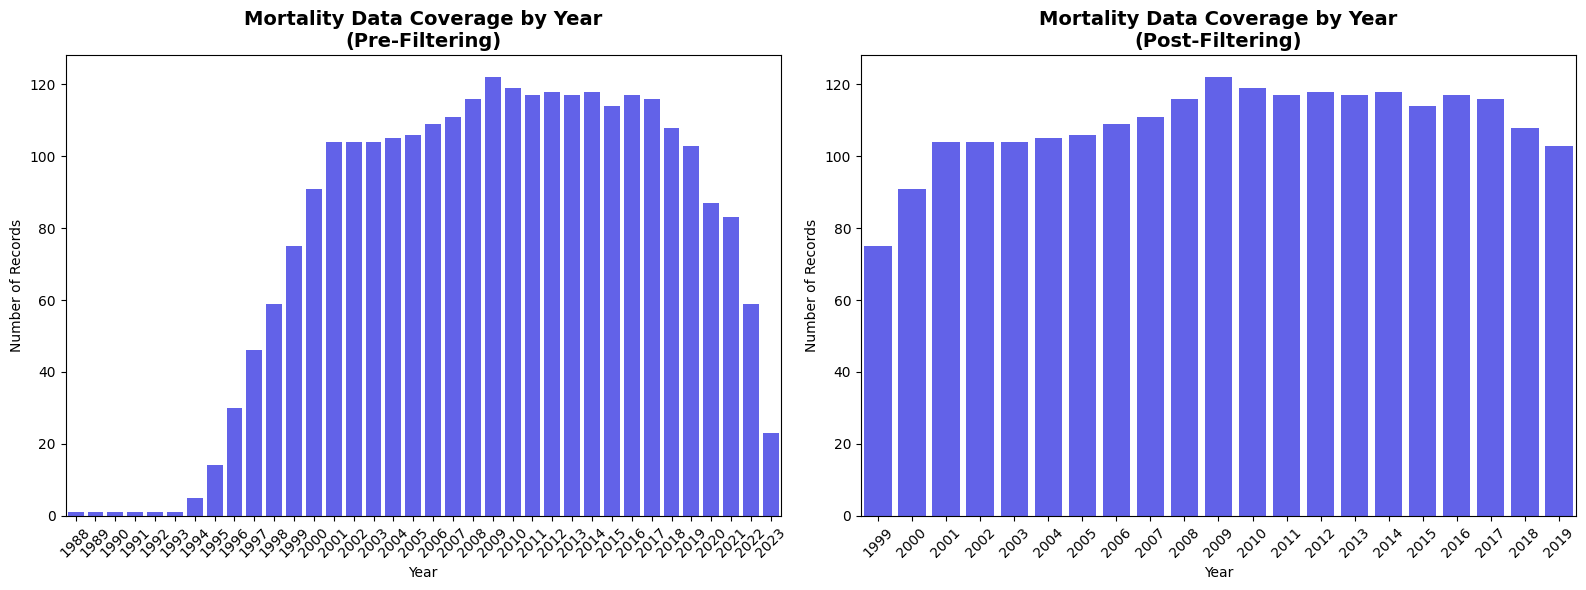

In [121]:
# Year Distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Get year counts from both dataframes
year_counts_pre = mortality_df_pre_filter["Year"].value_counts().sort_index()
year_counts_post = mortality_df["Year"].value_counts().sort_index()

# Find the common year range and maximum count for consistent scaling
all_years = sorted(set(year_counts_pre.index) | set(year_counts_post.index))
max_count = max(year_counts_pre.max(), year_counts_post.max())

# Left plot: Year distribution from pre-filtering data
sns.barplot(x=year_counts_pre.index, y=year_counts_pre.values,
           alpha=0.7, color="blue", ax=ax1)
ax1.set_title("Mortality Data Coverage by Year\n(Pre-Filtering)", fontsize=14, fontweight="bold")
ax1.set_xlabel("Year")
ax1.set_ylabel("Number of Records")
ax1.tick_params(axis='x', rotation=45)
ax1.set_ylim(0, max_count * 1.05)

# Right plot: Year distribution from post-filtering data
sns.barplot(x=year_counts_post.index, y=year_counts_post.values,
           alpha=0.7, color="blue", ax=ax2)
ax2.set_title("Mortality Data Coverage by Year\n(Post-Filtering)", fontsize=14, fontweight="bold")
ax2.set_xlabel("Year")
ax2.set_ylabel("Number of Records")
ax2.tick_params(axis='x', rotation=45)
ax2.set_ylim(0, max_count * 1.05)

plt.tight_layout()
plt.show()

##### Geographic Coverage or Missing Countries

In [122]:
# Geogrpahic Data Coverage
# Create side-by-side choropleth maps
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# Create subplot figure with 1 row, 2 columns
fig = make_subplots(
    rows=1, cols=2,
    specs=[[{"type": "geo"}, {"type": "geo"}]],
    subplot_titles=("Countries with Data Coverage", "Countries with Missing Data"),
    horizontal_spacing=0.05
)

# Left map: Countries with data coverage
all_countries_covered = list(exact_matches) + list(mortality_to_climate_mapping.values())
df_covered = pd.DataFrame(
    {"country": all_countries_covered, "status": ["Has Data"] * len(all_countries_covered)}
)

# Add covered data trace
fig.add_trace(
    go.Choropleth(
        locations=df_covered["country"],
        locationmode="country names",
        z=[1] * len(df_covered),  # Dummy values for coloring
        colorscale=[[0, "steelblue"], [1, "steelblue"]],
        showscale=False,
        name="Has Data",
        hovertemplate="<b>%{location}</b><br>Status: Has Data<extra></extra>"
    ),
    row=1, col=1
)

# Right map: Countries with missing data (assuming you have a missing_countries list or df)
# Replace 'missing_countries_list' with your actual missing countries data
# For example, if you have a missing_data df with country names:
missing_countries_list = missing_countries_df["Country"].unique().tolist()  # Adjust column name as needed

df_missing = pd.DataFrame(
    {"country": missing_countries_list, "status": ["Missing Data"] * len(missing_countries_list)}
)

# Add missing data trace
fig.add_trace(
    go.Choropleth(
        locations=df_missing["country"],
        locationmode="country names",
        z=[1] * len(df_missing),  # Dummy values for coloring
        colorscale=[[0, "red"], [1, "red"]],
        showscale=False,
        name="Missing Data",
        hovertemplate="<b>%{location}</b><br>Status: Missing Data<extra></extra>"
    ),
    row=1, col=2
)

# Update geo properties for both subplots
fig.update_geos(
    bgcolor="white",
    landcolor="lightgray",
    projection_type="natural earth"
)

# Update layout
fig.update_layout(
    width=1400,
    height=600,
    title_text="Data Coverage vs Missing Data by Country",
    title_font_size=20,
    title_x=0.5,
    showlegend=True
)

fig.show()

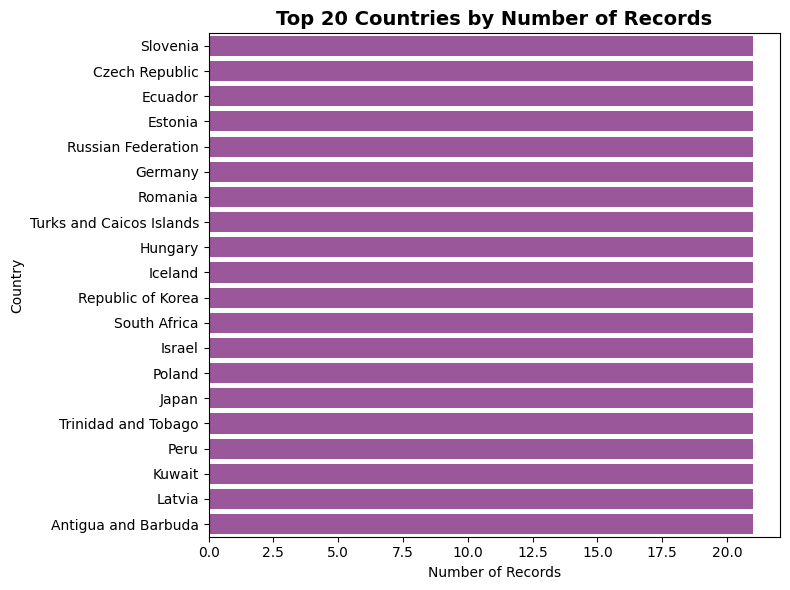

In [123]:
# Top Countries by Data Coverage
plt.figure(figsize=(8, 6))
country_counts = merged_df["Country_Name"].value_counts().head(20)
sns.barplot(y=country_counts.index, x=country_counts.values, alpha=0.7, color="purple")
plt.title("Top 20 Countries by Number of Records", fontsize=14, fontweight="bold")
plt.xlabel("Number of Records")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

####Climate data distributions



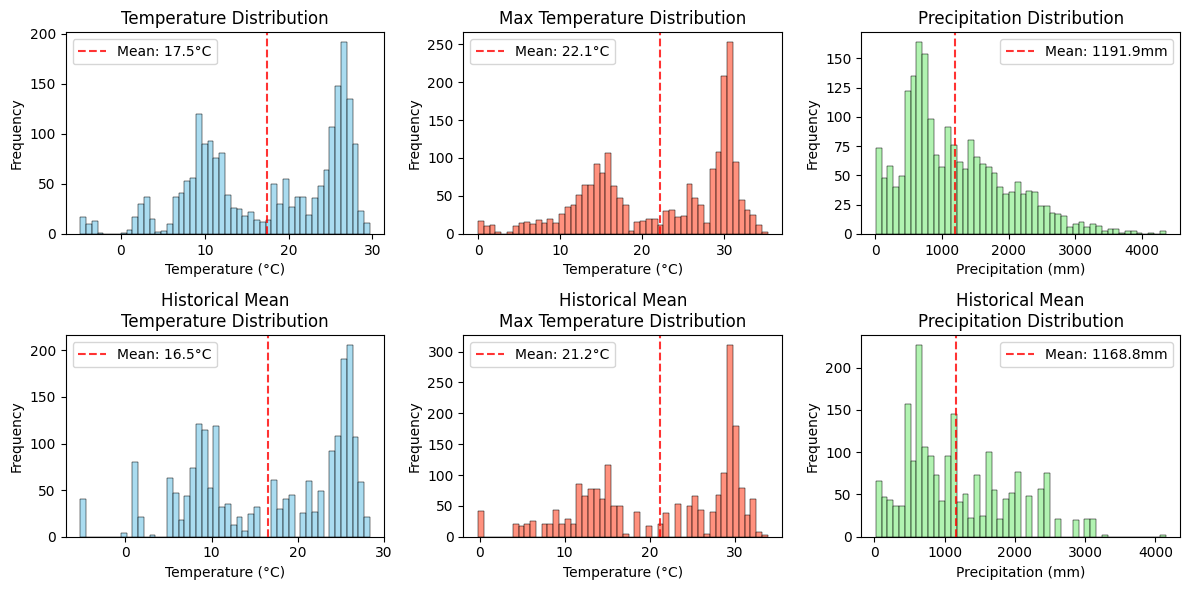

In [124]:
# Temperature and Precipitation Histograms

# list of tuples for: (Varaible, title, axis label, color)
plot_vars = [
    ("Temperature", "Temperature Distribution", "Temperature (°C)", "skyblue"),
    ("Max_Temperature", "Max Temperature Distribution", "Temperature (°C)", "tomato"),
    ("Precipitation", "Precipitation Distribution", "Precipitation (mm)", "lightgreen"),
    ("base_Temperature", "Historical Mean\nTemperature Distribution", "Temperature (°C)", "skyblue"),
    ("base_Max_Temperature", "Historical Mean\nMax Temperature Distribution", "Temperature (°C)", "tomato"),
    ("base_Precipitation", "Historical Mean\nPrecipitation Distribution", "Precipitation (mm)", "lightgreen"),

]

fig, axes = plt.subplots(2, 3, figsize=(12, 6))

for idx, (var, title, xlabel, color) in enumerate(plot_vars):
    row, col = divmod(idx, 3)
    ax = axes[row, col]
    sns.histplot(
        data=merged_df,
        x=var,
        bins=50,
        alpha=0.7,
        color=color,
        ax=ax
    )
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Frequency")
    mean_val = merged_df[var].mean()
    ax.axvline(
        mean_val,
        color="red",
        linestyle="--",
        alpha=0.8,
        label=f"Mean: {mean_val:.1f}{'°C' if 'Temperature' in var else 'mm'}"
    )
    ax.legend()

plt.tight_layout()
plt.show()

### Bivariate Data Analysis

Top 5 Causes of Death:
134,011,374: Diseases of the circulatory system
74,629,159: Neoplasms
32,518,982: Diseases of the respiratory system
29,815,906: External causes of morbidity and mortality - Including: Injury, poisoningand certain other consequences of external causes
20,796,965: Symptoms, signs and abnormal clinical and laboratory findings, not elsewhere classified


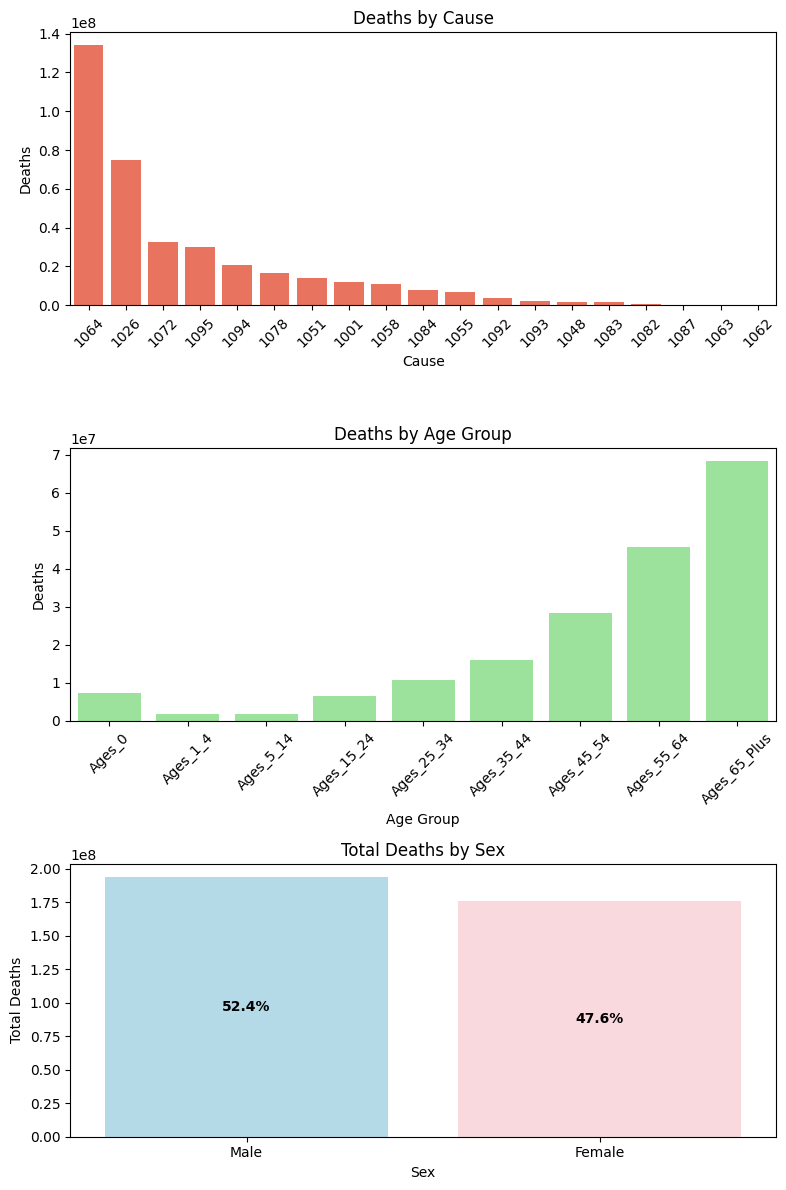

In [125]:
# Visualization: Total Deaths by Cause, Age Group, and Sex

fig, axes = plt.subplots(3, 1, figsize=(8, 12))

# --- Subplot 1: Total Deaths by Cause ---
# Identify all cause columns (excluding Cause_1000)
cause_cols = [
    col for col in merged_df.columns if col.startswith("Cause_") and col != "Cause_1000"
]
cause_totals = merged_df[cause_cols].sum().reset_index()
cause_totals.columns = ["Cause", "Deaths"]
cause_totals["Cause"] = cause_totals["Cause"].str.replace("Cause_", "")
cause_totals = cause_totals.sort_values("Deaths", ascending=False)
sns.barplot(data=cause_totals, x="Cause", y="Deaths", ax=axes[0], color = 'tomato')
axes[0].set_title("Deaths by Cause")
axes[0].set_xlabel("Cause")
axes[0].set_ylabel("Deaths")
axes[0].tick_params(axis="x", rotation=45)

# --- Subplot 2: Total Deaths by Age Group ---
age_bins = [
    col for col in merged_df.columns if col.startswith("Ages_")
]
age_group_totals = merged_df[age_bins].sum().reset_index()
age_group_totals.columns = ["Age_Group", "Deaths"]
sns.barplot(data=age_group_totals, x="Age_Group", y="Deaths", ax=axes[1], color='lightgreen')
axes[1].set_title("Deaths by Age Group")
axes[1].set_xlabel("Age Group")
axes[1].set_ylabel("Deaths")
axes[1].tick_params(axis="x", rotation=45)

# --- Subplot 3: Total Deaths by Sex ---
if "Sex_1" in merged_df.columns and "Sex_2" in merged_df.columns:
    total_male = merged_df["Sex_1"].sum()
    total_female = merged_df["Sex_2"].sum()
    sex_data = pd.DataFrame(
        {"Sex": ["Male", "Female"], "Deaths": [total_male, total_female]}
    )
    sns.barplot(
        data=sex_data,
        x="Sex",
        y="Deaths",
        hue="Sex",
        alpha=0.7,
        palette=["skyblue", "pink"],
        legend=False,
        ax=axes[2],
    )
    axes[2].set_title("Total Deaths by Sex")
    axes[2].set_xlabel("Sex")
    axes[2].set_ylabel("Total Deaths")
    total = total_male + total_female
    axes[2].text(
        0,
        total_male / 2,
        f"{total_male / total * 100:.1f}%",
        ha="center",
        va="center",
        fontweight="bold",
    )
    axes[2].text(
        1,
        total_female / 2,
        f"{total_female / total * 100:.1f}%",
        ha="center",
        va="center",
        fontweight="bold",
    )

# Print Top 5 causes of death
# Clean up cause names for display and convert to int for mapping
cause_totals["Cause_Code"] = cause_totals["Cause"].str.replace("Cause_", "").astype(int)

# Map to descriptions
cause_totals["Description"] = cause_totals["Cause_Code"].map(cause_descriptions)

# Sort in descending order by deaths
cause_totals = cause_totals.sort_values("Deaths", ascending=False)

# Print the top five causes with full numbers and descriptions
print("Top 5 Causes of Death:")
for _, row in cause_totals.head(5).iterrows():
    print(f"{int(row['Deaths']):,}: {row['Description']}")


plt.tight_layout()
plt.show()

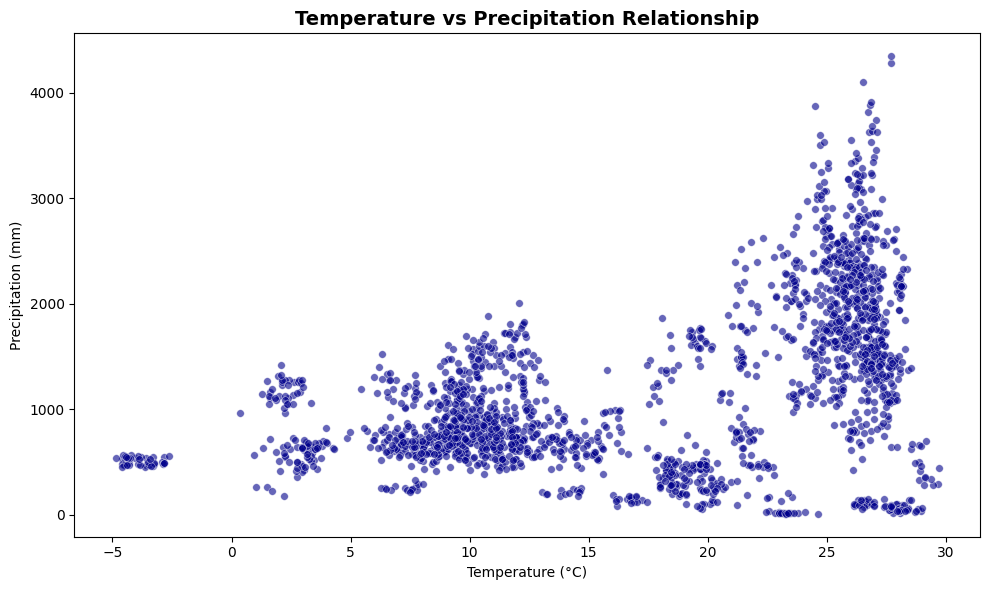

In [126]:
# Climate Variables Relationship
plt.figure(figsize=(10, 6))
# Sample data for better visualization if dataset is large
sample_data = (
    merged_df.sample(min(2000, len(merged_df))) if len(merged_df) > 2000 else merged_df
)

sns.scatterplot(
    data=sample_data,
    x="Temperature",
    y="Precipitation",
    alpha=0.6,
    s=30,
    color="darkblue",
)
plt.title("Temperature vs Precipitation Relationship", fontsize=14, fontweight="bold")
plt.xlabel("Temperature (°C)")
plt.ylabel("Precipitation (mm)")
plt.tight_layout()
plt.show()

Estimated rate of Temperature increase per year: -0.0377 °C/year (R²=0.566)
Estimated rate of diff_Temperature increase per year: 0.0315 °C/year (R²=0.681)


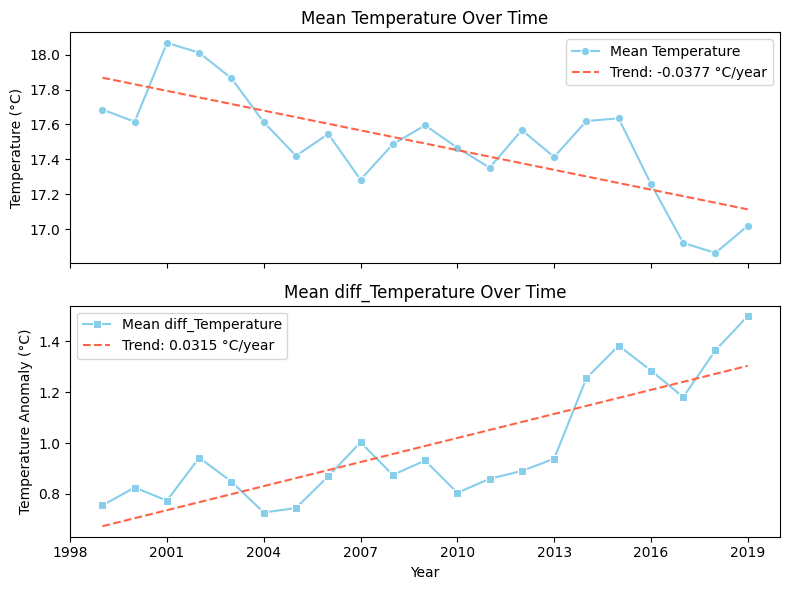

In [127]:
# Yearly Mean Temperature and diff_Temperature

from scipy.stats import linregress

# Calculate yearly means
yearly_means = merged_df.groupby("Year")[["Temperature", "diff_Temperature"]].mean().reset_index()

# Linear regression for Temperature
slope_temp, intercept_temp, r_temp, p_temp, std_err_temp = linregress(yearly_means["Year"], yearly_means["Temperature"])
# Linear regression for diff_Temperature
slope_diff, intercept_diff, r_diff, p_diff, std_err_diff = linregress(yearly_means["Year"], yearly_means["diff_Temperature"])

print(f"Estimated rate of Temperature increase per year: {slope_temp:.4f} °C/year (R²={r_temp**2:.3f})")
print(f"Estimated rate of diff_Temperature increase per year: {slope_diff:.4f} °C/year (R²={r_diff**2:.3f})")

# Plot both in subplots
fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

# Temperature subplot
sns.lineplot(data=yearly_means, x="Year", y="Temperature", marker="o", ax=axes[0], label="Mean Temperature", color = 'skyblue')
axes[0].plot(yearly_means["Year"], intercept_temp + slope_temp * yearly_means["Year"], color="tomato", linestyle="--", label=f"Trend: {slope_temp:.4f} °C/year")
axes[0].set_title("Mean Temperature Over Time")
axes[0].set_ylabel("Temperature (°C)")
axes[0].legend()

# diff_Temperature subplot
sns.lineplot(data=yearly_means, x="Year", y="diff_Temperature", marker="s", ax=axes[1], label="Mean diff_Temperature", color = 'skyblue')
axes[1].plot(yearly_means["Year"], intercept_diff + slope_diff * yearly_means["Year"], color="tomato", linestyle="--", label=f"Trend: {slope_diff:.4f} °C/year")
axes[1].set_title("Mean diff_Temperature Over Time")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Temperature Anomaly (°C)")
axes[1].legend()
axes[0].xaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

/Users/auston/Documents/MADS/Classes/SIADS 593 Milestone I/milestone_project/.venv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning:

divide by zero encountered in matmul

/Users/auston/Documents/MADS/Classes/SIADS 593 Milestone I/milestone_project/.venv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning:

overflow encountered in matmul

/Users/auston/Documents/MADS/Classes/SIADS 593 Milestone I/milestone_project/.venv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning:

invalid value encountered in matmul

/Users/auston/Documents/MADS/Classes/SIADS 593 Milestone I/milestone_project/.venv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning:

divide by zero encountered in matmul

/Users/auston/Documents/MADS/Classes/SIADS 593 Milestone I/milestone_project/.venv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning:

overflow encountered in matmul

/Users/auston/Documents/MADS

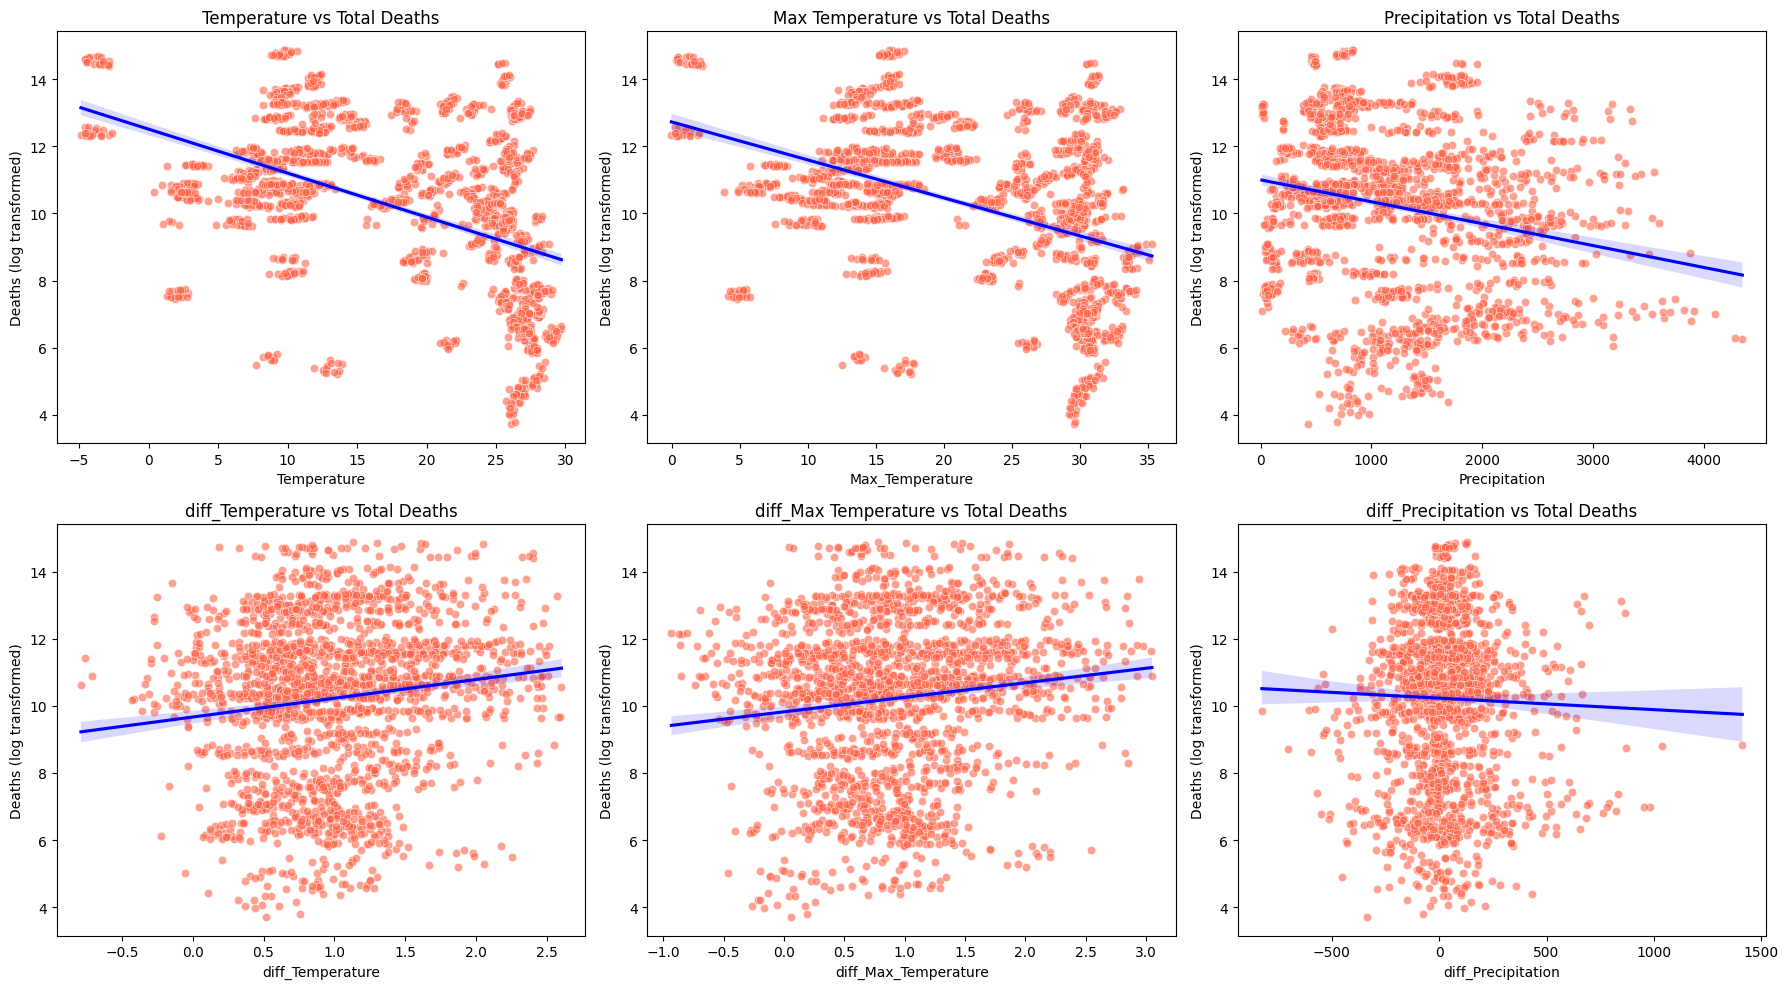

In [128]:
# Climate Metrics vs All Mortality

metrics = [
    ("Temperature", "Temperature vs Total Deaths"),
    ("Max_Temperature", "Max Temperature vs Total Deaths"),
    ("Precipitation", "Precipitation vs Total Deaths"),
    ("diff_Temperature", "diff_Temperature vs Total Deaths"),
    ("diff_Max_Temperature", "diff_Max Temperature vs Total Deaths"),
    ("diff_Precipitation", "diff_Precipitation vs Total Deaths"),
]

plt.figure(figsize=(18, 10))


for idx, (x_var, title) in enumerate(metrics, 1):
    plt.subplot(2, 3, idx)
    sns.scatterplot(data=merged_df, x=x_var, y="log_Cause_1000",alpha=0.6, color='tomato')
    sns.regplot(data=merged_df, x=x_var, y="log_Cause_1000", scatter=False, color='blue')
    plt.xlabel(x_var)
    plt.ylabel("Deaths (log transformed)")
    plt.title(title)

plt.tight_layout()
plt.show()

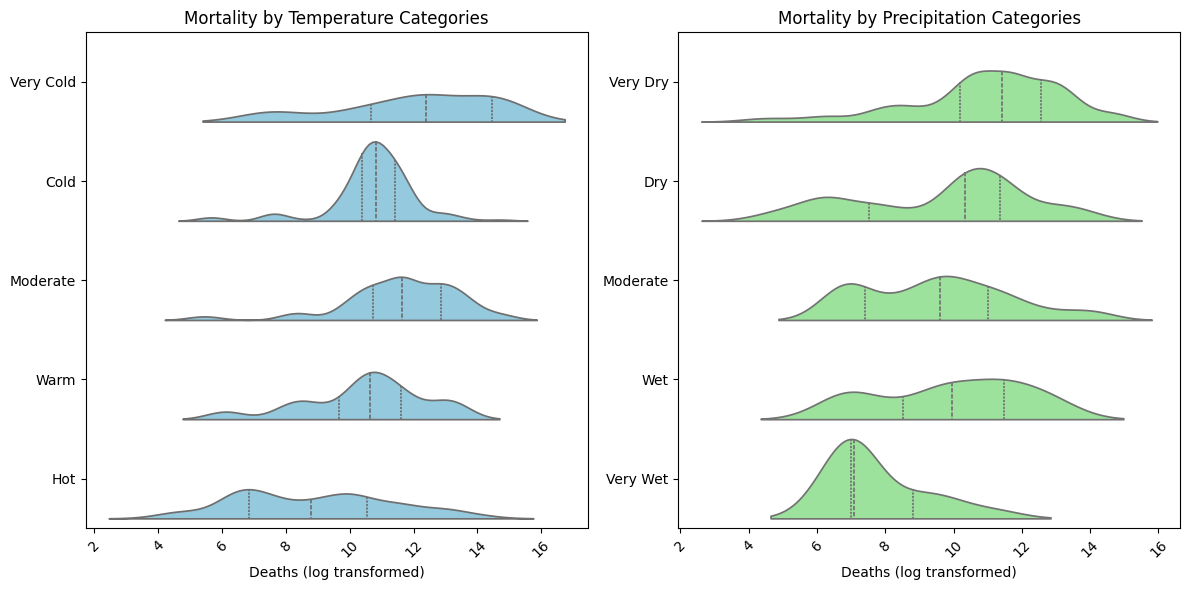

In [129]:
# Create temperature bins to see mortality patterns
merged_df["temp_bins"] = pd.cut(
    merged_df["Temperature"],
    bins=5,
    labels=["Very Cold", "Cold", "Moderate", "Warm", "Hot"],
)

merged_df["precip_bins"] = pd.cut(
    merged_df["Precipitation"],
    bins=5,
    labels=["Very Dry", "Dry", "Moderate", "Wet", "Very Wet"],
)

# Box plots showing mortality distribution by climate bins
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.violinplot(data=merged_df,
               x="log_Cause_1000",
               y="temp_bins",
               inner = 'quart',
               color ='skyblue',
               split = True
               )

plt.title("Mortality by Temperature Categories")
plt.xticks(rotation=45)
plt.xlabel("Deaths (log transformed)")
plt.ylabel(None)

plt.subplot(1, 2, 2)
sns.violinplot(data=merged_df,
               x="log_Cause_1000",
               y="precip_bins",
               inner = 'quart',
               color = 'lightgreen',
               split = True
               )

plt.title("Mortality by Precipitation Categories")
plt.xticks(rotation=45)
plt.xlabel("Deaths (log transformed)")
plt.ylabel(None)

plt.tight_layout()
plt.show()

### Multivariate Data Analysis

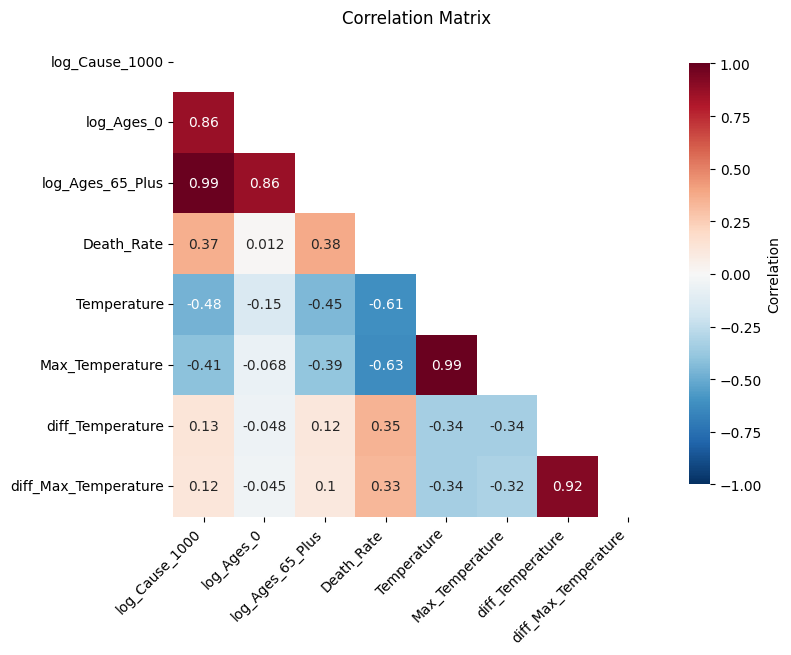

In [130]:
# Correlation Matrix of key variables
key_vars = ["log_Cause_1000", 'log_Ages_0', 'log_Ages_65_Plus', 'Death_Rate',
            'Temperature', 'Max_Temperature', 'diff_Temperature', 'diff_Max_Temperature']
corr_matrix = merged_df[key_vars].corr()

# Create a mask to remove top right triangle - removes duplicate correlations
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(8, 8))
sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,  # False remove numbers
            cmap='RdBu_r',
            center=0,
            square=True,
            cbar_kws={'label': 'Correlation', 'shrink':.6},
            vmin=-1,
            vmax=1)
plt.title('Correlation Matrix')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# Interactive Global Trends Visualization
# Aggregate all country data by year to examine worldwide patterns

# Sum mortality data and average climate data across all countries by year
yearly_data = merged_df.groupby('Year').agg({
    'All_Ages': 'sum',
    'Ages_0': 'sum',
    'Ages_1_4': 'sum',
    'Ages_5_14': 'sum',
    'Ages_15_24': 'sum',
    'Ages_25_34': 'sum',
    'Ages_35_44': 'sum',
    'Ages_45_54': 'sum',
    'Ages_55_64': 'sum',
    'Ages_65_Plus': 'sum',
    'Sex_1': 'sum',
    'Sex_2': 'sum',
    'Sex_9': 'sum',
    'Cause_1000': 'sum',
    'Cause_1001': 'sum',
    'Cause_1026': 'sum',
    'Cause_1048': 'sum',
    'Cause_1051': 'sum',
    'Cause_1055': 'sum',
    'Cause_1058': 'sum',
    'Cause_1062': 'sum',
    'Cause_1063': 'sum',
    'Cause_1064': 'sum',
    'Cause_1072': 'sum',
    'Cause_1078': 'sum',
    'Cause_1082': 'sum',
    'Cause_1083': 'sum',
    'Cause_1084': 'sum',
    'Cause_1087': 'sum',
    'Cause_1092': 'sum',
    'Cause_1093': 'sum',
    'Cause_1094': 'sum',
    'Cause_1095': 'sum',
    'Death_Rate': 'mean',           # Average death rate across countries
    'Temperature': 'mean',          # Global temperature average
    'Max_Temperature': 'mean',      # Global max temperature average
    'diff_Temperature': 'mean',     # Average temperature differential
    'diff_Max_Temperature': 'mean',
    'Total_Population': 'sum'       # Total global population
}).reset_index()

# Extract variable names for widget options
all_variables = [col for col in yearly_data.columns if col != 'Year']

def plot_trends(*variables):
    """
    Create time series plot for selected variables
    Uses dual y-axes: climate variables on right, mortality/population on left
    """
    fig = make_subplots(specs=[[{"secondary_y": True}]])

    # Color palette for multiple variables
    colors = ['red', 'blue', 'orange', 'green', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan']

    # Climate variables use right axis for appropriate scaling
    climate_vars = ['Temperature', 'Max_Temperature', 'diff_Temperature', 'diff_Max_Temperature']

    for i, var in enumerate(variables):
        if var not in yearly_data.columns:
            print(f"Warning: '{var}' not found in data!")
            continue

        color = colors[i % len(colors)]
        use_right_axis = var in climate_vars

        fig.add_trace(
            go.Scatter(
                x=yearly_data['Year'],
                y=yearly_data[var],
                mode='lines+markers',
                name=var,
                line={'color': color, 'width': 3},
                marker={'size': 6}
            ),
            secondary_y=use_right_axis
        )

    # Configure plot layout and axis labels
    fig.update_layout(
        title="Global Trends Over Time (1999-2019)",
        xaxis_title="Year",
        height=600
    )
    fig.update_yaxes(title_text="Deaths/Population/Rates", secondary_y=False)
    fig.update_yaxes(title_text="Temperature (°C)", secondary_y=True)
    fig.show()

# Set up interactive controls
variable_selector = widgets.SelectMultiple(
    options=all_variables,
    value=['All_Ages', 'Temperature', 'Death_Rate'],
    description='Variables (hold Ctrl/Cmd):',
    rows=15,
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='400px')
)

output = widgets.Output()

def update_plot(selected_variables):
    """Update visualization based on user variable selection"""
    if len(selected_variables) == 0:
        print("Please select at least one variable to plot")
        return

    print(f"Selected variables: {', '.join(selected_variables)}")
    print()

    # Generate the plot
    plot_trends(*selected_variables)

    # Calculate and display correlations for multiple variables
    if len(selected_variables) > 1:
        print("\nGlobal correlations:")
        corr_data = yearly_data[selected_variables].corr()

        for i, var1 in enumerate(selected_variables):
            for var2 in selected_variables[i+1:]:
                corr_val = corr_data.loc[var1, var2]
                print(f"{var1} vs {var2}: {corr_val:.3f}")

def on_variable_change(change):
    """Handle widget value changes"""
    with output:
        clear_output(wait=True)
        selected_vars = list(change['new'])
        update_plot(selected_vars)

# Connect widget to callback function
variable_selector.observe(on_variable_change, names='value')

# Display available variable categories for user reference
print("ALL AVAILABLE VARIABLES:")
print("\nAGE GROUPS:")
age_vars = [col for col in yearly_data.columns if col.startswith('Ages_')]
print(age_vars)

print("\nSEX CATEGORIES:")
sex_vars = [col for col in yearly_data.columns if col.startswith('Sex_')]
print(sex_vars)

print("\nCAUSES OF DEATH:")
cause_vars = [col for col in yearly_data.columns if col.startswith('Cause_')]
print(cause_vars)

print("\nCLIMATE VARIABLES:")
climate_vars = ['Temperature', 'Max_Temperature', 'diff_Temperature', 'diff_Max_Temperature']
print(climate_vars)

print("\nOTHER:")
other_vars = ['All_Ages', 'Death_Rate', 'Total_Population']
print(other_vars)

print(f"\nTOTAL: {len(all_variables)} variables available!")

# Set up user interface
print("\n" + "="*60)
print("GLOBAL TRENDS WITH INTERACTIVE VARIABLE SELECTION")
print("Select multiple variables to plot global trends over time")
print("Data is aggregated globally (summed across all countries)")
print("="*60)

display(variable_selector)
display(output)

# Initialize with default selection
with output:
    update_plot(list(variable_selector.value))

ALL AVAILABLE VARIABLES:

AGE GROUPS:
['Ages_0', 'Ages_1_4', 'Ages_5_14', 'Ages_15_24', 'Ages_25_34', 'Ages_35_44', 'Ages_45_54', 'Ages_55_64', 'Ages_65_Plus']

SEX CATEGORIES:
['Sex_1', 'Sex_2', 'Sex_9']

CAUSES OF DEATH:
['Cause_1000', 'Cause_1001', 'Cause_1026', 'Cause_1048', 'Cause_1051', 'Cause_1055', 'Cause_1058', 'Cause_1062', 'Cause_1063', 'Cause_1064', 'Cause_1072', 'Cause_1078', 'Cause_1082', 'Cause_1083', 'Cause_1084', 'Cause_1087', 'Cause_1092', 'Cause_1093', 'Cause_1094', 'Cause_1095']

CLIMATE VARIABLES:
['Temperature', 'Max_Temperature', 'diff_Temperature', 'diff_Max_Temperature']

OTHER:
['All_Ages', 'Death_Rate', 'Total_Population']

TOTAL: 39 variables available!

GLOBAL TRENDS WITH INTERACTIVE VARIABLE SELECTION
Select multiple variables to plot global trends over time
Data is aggregated globally (summed across all countries)


SelectMultiple(description='Variables (hold Ctrl/Cmd):', index=(0, 34, 33), layout=Layout(width='400px'), opti…

Output()

In [ ]:
# Interactive Country-Specific Analysis
# Examine individual country trends without aggregation

# Get available countries and numeric variables
available_countries = sorted(merged_df['Country_Name'].dropna().unique())

numeric_columns = merged_df.select_dtypes(include=['number']).columns.tolist()
# Remove non-plotting variables
if 'Year' in numeric_columns:
    numeric_columns.remove('Year')
if 'Country_Code' in numeric_columns:
    numeric_columns.remove('Country_Code')

# Create user interface widgets
country_dropdown = widgets.Dropdown(
    options=available_countries,
    value='Czech Republic',
    description='Country:',
    style={'description_width': 'initial'}
)

variable_selector = widgets.SelectMultiple(
    options=numeric_columns,
    value=['All_Ages', 'Temperature', 'Death_Rate'],
    description='Variables (hold Ctrl/Cmd):',
    rows=12,
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='400px')
)

output2 = widgets.Output()

def plot_country_trends(country_name, *variables):
    """
    Generate time series plot for specific country
    No data aggregation - shows actual country values over time
    """
    # Filter to selected country only
    country_data = merged_df[merged_df['Country_Name'] == country_name].copy()

    if len(country_data) == 0:
        print(f"No data available for {country_name}")
        return

    # Sort chronologically
    country_data = country_data.sort_values('Year').reset_index(drop=True)

    fig = make_subplots(specs=[[{"secondary_y": True}]])
    colors = ['red', 'blue', 'orange', 'green', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan']

    # Separate climate variables for right axis scaling
    climate_vars = ['Temperature', 'Max_Temperature', 'diff_Temperature', 'diff_Max_Temperature']

    for i, var in enumerate(variables):
        if var not in country_data.columns:
            print(f"Warning: '{var}' not found in data!")
            continue

        color = colors[i % len(colors)]
        use_right_axis = var in climate_vars

        fig.add_trace(
            go.Scatter(
                x=country_data['Year'],
                y=country_data[var],
                mode='lines+markers',
                name=var,
                line={'color': color, 'width': 3},
                marker={'size': 6}
            ),
            secondary_y=use_right_axis
        )

    # Configure plot appearance
    fig.update_layout(
        title=f"{country_name} Trends Over Time ({country_data['Year'].min()}-{country_data['Year'].max()})",
        xaxis_title="Year",
        height=600
    )
    fig.update_yaxes(title_text="Deaths/Population/Rates", secondary_y=False)
    fig.update_yaxes(title_text="Temperature (°C)", secondary_y=True)
    fig.show()

def analyze_country(country_name, selected_variables):
    """Main analysis function combining data summary, plotting, and correlations"""
    with output2:
        clear_output(wait=True)

        if len(selected_variables) == 0:
            print("Please select at least one variable to plot")
            return

        # Display data availability info
        country_data = merged_df[merged_df['Country_Name'] == country_name]
        print(f"{country_name} data available for years: {country_data['Year'].min()} to {country_data['Year'].max()}")
        print(f"Number of data points: {len(country_data)}")
        print(f"Selected variables: {', '.join(selected_variables)}")
        print()

        # Generate visualization
        plot_country_trends(country_name, *selected_variables)

        # Calculate country-specific correlations
        if len(selected_variables) > 1 and len(country_data) > 1:
            print(f"\n{country_name} correlations:")
            corr_data = country_data[selected_variables].corr()

            for i, var1 in enumerate(selected_variables):
                for var2 in selected_variables[i+1:]:
                    if var1 in corr_data.columns and var2 in corr_data.columns:
                        corr_val = corr_data.loc[var1, var2]
                        print(f"{var1} vs {var2}: {corr_val:.3f}")

def on_change(change):
    """Handle changes to either country or variable selection"""
    analyze_country(country_dropdown.value, list(variable_selector.value))

# Link widgets to update function
country_dropdown.observe(on_change, names='value')
variable_selector.observe(on_change, names='value')

# Show available variable categories
print("ALL AVAILABLE VARIABLES:")
print("\nAGE GROUPS:")
age_vars = [col for col in numeric_columns if col.startswith('Ages_')]
print(age_vars)

print("\nSEX CATEGORIES:")
sex_vars = [col for col in numeric_columns if col.startswith('Sex_')]
print(sex_vars)

print("\nCAUSES OF DEATH:")
cause_vars = [col for col in numeric_columns if col.startswith('Cause_')]
print(cause_vars)

print("\nCLIMATE VARIABLES:")
climate_vars = ['Temperature', 'Max_Temperature', 'diff_Temperature', 'diff_Max_Temperature']
print(climate_vars)

print("\nOTHER:")
other_vars = ['All_Ages', 'Death_Rate', 'Total_Population']
print(other_vars)

print(f"\nTOTAL: {len(numeric_columns)} variables available!")

# Display interface
print("\n" + "="*60)
print("COUNTRY-SPECIFIC ANALYSIS WITH VARIABLE SELECTION")
print("Select country and multiple variables to plot together")
print("Variables are plotted as-is (no aggregation/summing)")
print("="*60)

controls = widgets.VBox([
    widgets.HBox([country_dropdown]),
    variable_selector
])

display(controls)
display(output2)

# Run initial analysis with default selections
analyze_country(country_dropdown.value, list(variable_selector.value))

ALL AVAILABLE VARIABLES:

AGE GROUPS:
['Ages_0', 'Ages_1_4', 'Ages_5_14', 'Ages_15_24', 'Ages_25_34', 'Ages_35_44', 'Ages_45_54', 'Ages_55_64', 'Ages_65_Plus']

SEX CATEGORIES:
['Sex_1', 'Sex_2', 'Sex_9']

CAUSES OF DEATH:
['Cause_1000', 'Cause_1001', 'Cause_1026', 'Cause_1048', 'Cause_1051', 'Cause_1055', 'Cause_1058', 'Cause_1062', 'Cause_1063', 'Cause_1064', 'Cause_1072', 'Cause_1078', 'Cause_1082', 'Cause_1083', 'Cause_1084', 'Cause_1087', 'Cause_1092', 'Cause_1093', 'Cause_1094', 'Cause_1095']

CLIMATE VARIABLES:
['Temperature', 'Max_Temperature', 'diff_Temperature', 'diff_Max_Temperature']

OTHER:
['All_Ages', 'Death_Rate', 'Total_Population']

TOTAL: 78 variables available!

COUNTRY-SPECIFIC ANALYSIS WITH VARIABLE SELECTION
Select country and multiple variables to plot together
Variables are plotted as-is (no aggregation/summing)


Output()

In [133]:
# Interactive Geographic Visualization: Temperature and Precipitation by Year
# Side-by-side choropleth maps with year selection dropdown

# Extract available years from dataset
available_years = sorted(merged_df["Year"].unique())

# Aggregate climate data by country and year for mapping
map_data = (
    merged_df.groupby(["Country_Name", "Year"])
    .agg({"Temperature": "mean", "Precipitation": "mean"})
    .reset_index()
)

# Initialize dual-map figure
fig = go.Figure()

# Create choropleth traces for each year (temperature and precipitation)
for i, year in enumerate(available_years):
    year_data = map_data[map_data["Year"] == year]

    # Left map: Temperature visualization
    fig.add_trace(
        go.Choropleth(
            locations=year_data.dropna(subset=["Temperature"])["Country_Name"],
            locationmode="country names",
            z=year_data.dropna(subset=["Temperature"])["Temperature"],
            colorscale="RdYlBu_r",  # Red-yellow-blue scale for temperature
            name=f"Temperature {year}",
            visible=(i == 0),  # Show only first year initially
            geo="geo1",  # Assign to left geographic subplot
            colorbar={
                "x": 0.46,  # Center position between maps
                "y": 0.5,
                "len": 0.8,
                "title": "Temperature (°C)"
            },
        )
    )

    # Right map: Precipitation visualization
    fig.add_trace(
        go.Choropleth(
            locations=year_data.dropna(subset=["Precipitation"])["Country_Name"],
            locationmode="country names",
            z=year_data.dropna(subset=["Precipitation"])["Precipitation"],
            colorscale="Viridis",  # Green-blue scale for precipitation
            name=f"Precipitation {year}",
            visible=(i == 0),
            geo="geo2",  # Assign to right geographic subplot
            colorbar={
                "x": 1.02,  # Position right of second map
                "y": 0.5,
                "len": 0.8,
                "title": "Precipitation (mm)"
            },
        )
    )

# Build year selection dropdown menu
dropdown_buttons = []
for i, year in enumerate(available_years):
    year_data = map_data[map_data["Year"] == year]
    temp_count = year_data["Temperature"].notna().sum()
    precip_count = year_data["Precipitation"].notna().sum()

    # Set visibility for this year's traces only
    visibility = [False] * (len(available_years) * 2)
    visibility[i * 2] = True  # Temperature trace
    visibility[i * 2 + 1] = True  # Precipitation trace

    dropdown_buttons.append(
        {
            "label": f"{year} (T:{temp_count}, P:{precip_count})",
            "method": "update",
            "args": [{"visible": visibility}],
        }
    )

# Configure layout with dual maps and interactive controls
fig.update_layout(
    title="Interactive Climate Maps by Year",
    title_x=0.5,
    title_y=0.95,
    width=1600,
    height=700,
    # Left geographic subplot for temperature
    geo1={
        "domain": {"x": [0, 0.42], "y": [0.1, 0.8]},
        "showframe": True,
        "showcoastlines": True,
        "projection_type": "natural earth",
    },
    # Right geographic subplot for precipitation
    geo2={
        "domain": {"x": [0.54, 0.96], "y": [0.1, 0.8]},
        "showframe": True,
        "showcoastlines": True,
        "projection_type": "natural earth",
    },
    # Year selection dropdown
    updatemenus=[
        {
            "buttons": dropdown_buttons,
            "direction": "down",
            "showactive": True,
            "x": 0.52,
            "xanchor": "center",
            "y": 1.07,
            "yanchor": "top",
            "bgcolor": "white",
            "bordercolor": "gray",
            "borderwidth": 1,
        }
    ],
    # Map labels and user instructions
    annotations=[
        {
            "text": "Temperature",
            "x": 0.17,
            "y": 0.82,
            "xref": "paper",
            "yref": "paper",
            "showarrow": False,
            "font": {"size": 16, "color": "black"},
        },
        {
            "text": "Precipitation",
            "x": 0.80,
            "y": 0.82,
            "xref": "paper",
            "yref": "paper",
            "showarrow": False,
            "font": {"size": 16, "color": "black"},
        },
        {
            "text": "Use dropdown to select year. Numbers show countries with data.",
            "x": 0.52,
            "y": 0.99,
            "xref": "paper",
            "yref": "paper",
            "showarrow": False,
            "font": {"size": 12, "color": "gray"},
            "xanchor": "center",
        },
    ],
)

fig.show()

In [134]:
# Interactive Geographic Visualization: Mortality Data by Year
# Dual choropleth maps showing total deaths and death rates with year selection

# Extract years available in mortality dataset
available_years = sorted(merged_df["Year"].unique())

# Aggregate mortality data by country and year
mortality_map_data = (
    merged_df.groupby(["Country_Name", "Year"])
    .agg({"All_Ages": "sum", "Sex_1": "sum", "Sex_2": "sum"})
    .reset_index()
)

# Initialize figure for dual mortality maps
fig = go.Figure()

# Generate choropleth traces for each year
for i, year in enumerate(available_years):
    year_data = mortality_map_data[mortality_map_data["Year"] == year]

    # Left map: Total deaths by country
    fig.add_trace(
        go.Choropleth(
            locations=year_data.dropna(subset=["All_Ages"])["Country_Name"],
            locationmode="country names",
            z=year_data.dropna(subset=["All_Ages"])["All_Ages"],
            colorscale="Reds",  # Red gradient for death counts
            name=f"Total Deaths {year}",
            visible=(i == 0),  # Display first year by default
            geo="geo1",
            colorbar={
                "x": 0.46,  # Center between maps
                "y": 0.5,
                "len": 0.8,
                "title": "Total Deaths"
            },
        )
    )

    # Calculate simplified death rate for visualization
    year_data_rate = year_data.copy()
    year_data_rate["Death_Rate"] = year_data_rate["All_Ages"] / 1000  # Deaths per 1000

    # Right map: Death rate visualization
    fig.add_trace(
        go.Choropleth(
            locations=year_data_rate.dropna(subset=["Death_Rate"])["Country_Name"],
            locationmode="country names",
            z=year_data_rate.dropna(subset=["Death_Rate"])["Death_Rate"],
            colorscale="OrRd",  # Orange-red scale for rates
            name=f"Death Rate {year}",
            visible=(i == 0),
            geo="geo2",
            colorbar={
                "x": 1.02,  # Right of second map
                "y": 0.5,
                "len": 0.8,
                "title": "Death Rate (per 1K)"
            },
        )
    )

# Create dropdown menu for year selection
dropdown_buttons = []
for i, year in enumerate(available_years):
    year_data = mortality_map_data[mortality_map_data["Year"] == year]
    total_deaths_count = year_data["All_Ages"].notna().sum()
    countries_count = len(year_data)

    # Configure trace visibility for selected year
    visibility = [False] * (len(available_years) * 2)
    visibility[i * 2] = True  # Total deaths map
    visibility[i * 2 + 1] = True  # Death rate map

    dropdown_buttons.append(
        {
            "label": f"{year} ({countries_count} countries)",
            "method": "update",
            "args": [{"visible": visibility}],
        }
    )

# Set up dual-map layout with interactive controls
fig.update_layout(
    title="Interactive Mortality Maps by Year",
    title_x=0.5,
    title_y=0.95,
    width=1600,
    height=700,
    # Left subplot: Total deaths
    geo1={
        "domain": {"x": [0, 0.42], "y": [0.1, 0.8]},
        "showframe": True,
        "showcoastlines": True,
        "projection_type": "natural earth",
    },
    # Right subplot: Death rates
    geo2={
        "domain": {"x": [0.54, 0.96], "y": [0.1, 0.8]},
        "showframe": True,
        "showcoastlines": True,
        "projection_type": "natural earth",
    },
    # Interactive year selector
    updatemenus=[
        {
            "buttons": dropdown_buttons,
            "direction": "down",
            "showactive": True,
            "x": 0.52,
            "xanchor": "center",
            "y": 1.07,
            "yanchor": "top",
            "bgcolor": "white",
            "bordercolor": "gray",
            "borderwidth": 1,
        }
    ],
    # Map titles and instructions
    annotations=[
        {
            "text": "Total Deaths",
            "x": 0.17,
            "y": 0.82,
            "xref": "paper",
            "yref": "paper",
            "showarrow": False,
            "font": {"size": 16, "color": "black"},
        },
        {
            "text": "Death Rate",
            "x": 0.80,
            "y": 0.82,
            "xref": "paper",
            "yref": "paper",
            "showarrow": False,
            "font": {"size": 16, "color": "black"},
        },
        {
            "text": "Use dropdown to select year. Shows mortality data by country.",
            "x": 0.52,
            "y": 0.99,
            "xref": "paper",
            "yref": "paper",
            "showarrow": False,
            "font": {"size": 12, "color": "gray"},
            "xanchor": "center",
        },
    ],
)

fig.show()

### Age Specific Analysis

In [135]:
# Age-stratified Correlation Analysis

# All age groups and climate variables

age_groups = ['All_Ages', 'log_Ages_0', 'log_Ages_1_4', 'log_Ages_5_14', 'log_Ages_15_24',
              'log_Ages_25_34','log_Ages_35_44', 'log_Ages_45_54', 'log_Ages_55_64', 'log_Ages_65_Plus']
climate_vars = ['Temperature', 'Max_Temperature', 'Precipitation', 'diff_Temperature',
                'diff_Max_Temperature', 'diff_Precipitation']

# Calculate all correlations in one go
results = []
for climate in climate_vars:
    for age in age_groups:
        r, p = pearsonr(merged_df[climate], merged_df[age])
        results.append({
            'Climate': climate,
            'Age': age,
            'r': r,
            'p': p,
            'significant': p < 0.05
        })

age_df = pd.DataFrame(results)
age_df.head()

,Climate,Age,r,p,significant
0,Temperature,All_Ages,-0.265,9.469e-35,True
1,Temperature,log_Ages_0,-0.155,1.219e-12,True
2,Temperature,log_Ages_1_4,-0.146,1.834e-11,True
3,Temperature,log_Ages_5_14,-0.173,1.688e-15,True
4,Temperature,log_Ages_15_24,-0.223,5.978e-25,True


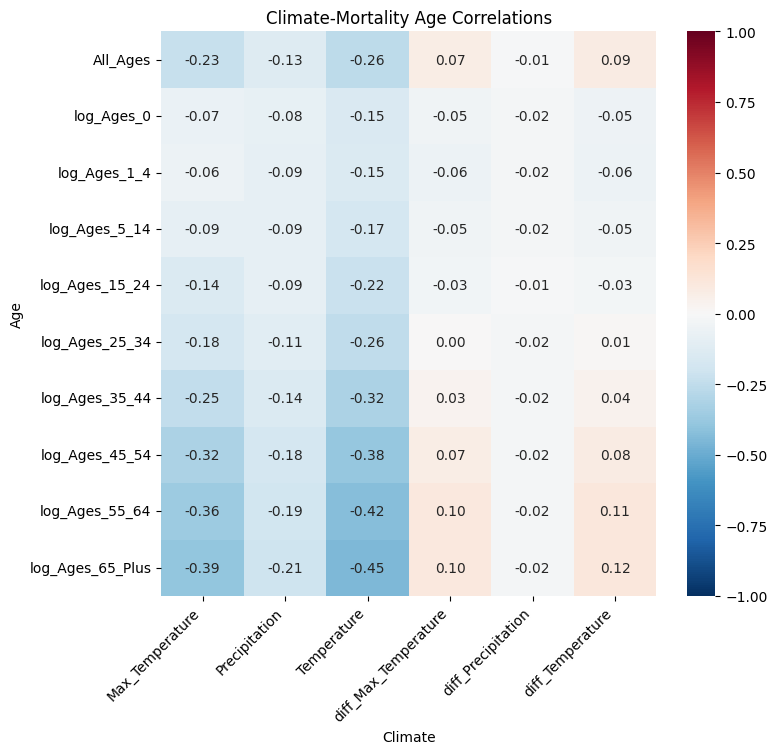


Significant correlations (p < 0.05): 45/60

Top relationships:
log_Ages_65_Plus vs Temperature: r=-0.452, p=0.000
log_Ages_55_64 vs Temperature: r=-0.425, p=0.000
log_Ages_65_Plus vs Max_Temperature: r=-0.391, p=0.000
log_Ages_45_54 vs Temperature: r=-0.385, p=0.000
log_Ages_55_64 vs Max_Temperature: r=-0.361, p=0.000
log_Ages_35_44 vs Temperature: r=-0.320, p=0.000
log_Ages_45_54 vs Max_Temperature: r=-0.318, p=0.000
All_Ages vs Temperature: r=-0.265, p=0.000
log_Ages_25_34 vs Temperature: r=-0.255, p=0.000
log_Ages_35_44 vs Max_Temperature: r=-0.248, p=0.000


In [136]:
# Create correlation heatmap
age_order = ['All_Ages', 'log_Ages_0', 'log_Ages_1_4', 'log_Ages_5_14', 'log_Ages_15_24',
             'log_Ages_25_34','log_Ages_35_44', 'log_Ages_45_54', 'log_Ages_55_64', 'log_Ages_65_Plus']


# Create correlation heatmap with proper ordering
pivot = age_df.pivot(index='Age', columns='Climate', values='r')
pivot = pivot.reindex(age_order)
plt.figure(figsize=(8, 8))
sns.heatmap(pivot, annot=True, cmap='RdBu_r', center=0, fmt='.2f',vmin=-1,vmax=1)
plt.title('Climate-Mortality Age Correlations')
plt.tight_layout()
plt.xticks(rotation=45, ha='right')
plt.show()

# Show most significant correlations
significant = age_df[age_df['significant']].sort_values('r', key=abs, ascending=False)
print(f"\nSignificant correlations (p < 0.05): {len(significant)}/{len(age_df)}")
print("\nTop relationships:")
for _, row in significant.head(10).iterrows():
    print(f"{row['Age']} vs {row['Climate']}: r={row['r']:.3f}, p={row['p']:.3f}")

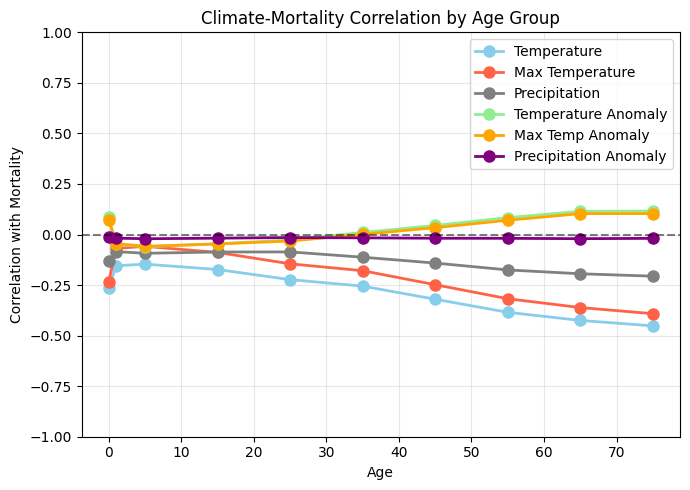

In [137]:
# Plot climate-mortality correlations by age

# Extract correlations for each variable
temp_data = age_df[age_df['Climate'] == 'Temperature'].copy().set_index('Age').reindex(age_groups)
max_temp_data = age_df[age_df['Climate'] == 'Max_Temperature'].copy().set_index('Age').reindex(age_groups)
precip_data = age_df[age_df['Climate'] == 'Precipitation'].copy().set_index('Age').reindex(age_groups)
diff_temp_data = age_df[age_df['Climate'] == 'diff_Temperature'].copy().set_index('Age').reindex(age_groups)
diff_precip_data = age_df[age_df['Climate'] == 'diff_Precipitation'].copy().set_index('Age').reindex(age_groups)
diff_max_temp_data = age_df[age_df['Climate'] == 'diff_Max_Temperature'].copy().set_index('Age').reindex(age_groups)

age_points = [0, 1, 5, 15, 25, 35, 45, 55, 65, 75]

plt.figure(figsize=(7, 5))
plt.plot(age_points, temp_data['r'], 'o-', linewidth=2, markersize=8, color='skyblue', label='Temperature')
plt.plot(age_points, max_temp_data['r'], 'o-', linewidth=2, markersize=8, color='tomato', label='Max Temperature')
plt.plot(age_points, precip_data['r'], 'o-', linewidth=2, markersize=8, color='grey', label='Precipitation')
plt.plot(age_points, diff_temp_data['r'], 'o-', linewidth=2, markersize=8, color='lightgreen', label='Temperature Anomaly')
plt.plot(age_points, diff_max_temp_data['r'], 'o-', linewidth=2, markersize=8, color='orange', label='Max Temp Anomaly')
plt.plot(age_points, diff_precip_data['r'], 'o-', linewidth=2, markersize=8, color='purple', label='Precipitation Anomaly')
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
plt.xlabel('Age')
plt.ylabel('Correlation with Mortality')
plt.title('Climate-Mortality Correlation by Age Group')
plt.ylim(-1, 1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Cause of Death Specific Analysis

In [138]:
# Age-stratified Correlation Analysis

# All age groups and climate variables
cause_groups = ['log_Cause_1000', 'log_Cause_1001', 'log_Cause_1026', 'log_Cause_1048',
                'log_Cause_1051', 'log_Cause_1055', 'log_Cause_1058', 'log_Cause_1062',
                'log_Cause_1063', 'log_Cause_1064', 'log_Cause_1072', 'log_Cause_1078',
                'log_Cause_1082','log_Cause_1083', 'log_Cause_1084', 'log_Cause_1087',
                'log_Cause_1092', 'log_Cause_1093', 'log_Cause_1094','log_Cause_1095']

climate_vars = ['Temperature', 'Max_Temperature', 'Precipitation', 'diff_Temperature',
                'diff_Max_Temperature', 'diff_Precipitation',]


# Calculate all correlations in one go
results = []
for climate in climate_vars:
    for cause in cause_groups:
        log_cause = merged_df[cause].apply(lambda x: np.log(x+1))
        r, p = pearsonr(merged_df[climate], log_cause)
        results.append({
            'Climate': climate,
            'Cause': cause,
            'r': r,
            'p': p,
            'significant': p < 0.05
        })

cause_df = pd.DataFrame(results)
cause_df.head()

,Climate,Cause,r,p,significant
0,Temperature,log_Cause_1000,-0.476,1.395e-118,True
1,Temperature,log_Cause_1001,-0.244,1.189e-29,True
2,Temperature,log_Cause_1026,-0.528,6.778e-150,True
3,Temperature,log_Cause_1048,-0.255,2.010e-32,True
4,Temperature,log_Cause_1051,-0.273,7.155e-37,True


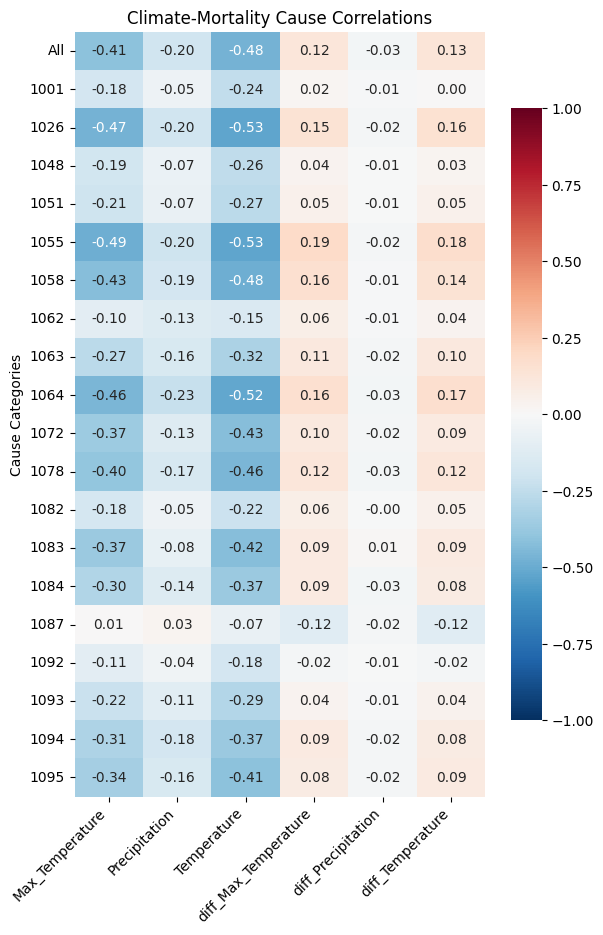


Significant correlations (p < 0.05): 90/60

Top relationships:
log_Cause_1055 vs Temperature: r=-0.528, p=0.000
log_Cause_1026 vs Temperature: r=-0.528, p=0.000
log_Cause_1064 vs Temperature: r=-0.522, p=0.000
log_Cause_1055 vs Max_Temperature: r=-0.490, p=0.000
log_Cause_1058 vs Temperature: r=-0.485, p=0.000
log_Cause_1000 vs Temperature: r=-0.476, p=0.000
log_Cause_1026 vs Max_Temperature: r=-0.472, p=0.000
log_Cause_1064 vs Max_Temperature: r=-0.460, p=0.000
log_Cause_1078 vs Temperature: r=-0.458, p=0.000
log_Cause_1072 vs Temperature: r=-0.429, p=0.000


In [139]:
# Create correlation heatmap
pivot = cause_df.pivot(index='Cause', columns='Climate', values='r')
yticklabels = ['All', '1001','1026','1048','1051','1055','1058','1062','1063','1064',
               '1072','1078','1082','1083','1084','1087','1092','1093','1094','1095']

plt.figure(figsize=(6, 10))
sns.heatmap(pivot,
            annot=True,
            cmap='RdBu_r',
            center=0,
            fmt='.2f',
            vmin=-1,
            vmax=1,
            yticklabels = yticklabels,
            cbar_kws={'shrink':.8}
            )
plt.title('Climate-Mortality Cause Correlations')
plt.tight_layout()
plt.xticks( rotation=45, ha='right')
plt.yticks(rotation=0)
plt.xlabel(None)

plt.ylabel("Cause Categories")
plt.show()

# Show most significant correlations
significant = cause_df[cause_df['significant']].sort_values('r', key=abs, ascending=False)
print(f"\nSignificant correlations (p < 0.05): {len(significant)}/{len(age_df)}")
print("\nTop relationships:")
for _, row in significant.head(10).iterrows():
    print(f"{row['Cause']} vs {row['Climate']}: r={row['r']:.3f}, p={row['p']:.3f}")

In [140]:
# Five most positively and negatively correlated Causes with diff_Temperature

# Select only 'diff_Temperature' from the climate variables
diff_temp_cause_df = cause_df[cause_df['Climate'] == 'diff_Temperature'].copy()

# Sort by absolute correlation value for diff_Temperature
diff_temp_cause_df = diff_temp_cause_df.sort_values('r', key=abs, ascending=False).reset_index(drop=True)

# Get the top 5 most positively correlated causes
most_positive_corr = diff_temp_cause_df[diff_temp_cause_df['r'] > 0].sort_values('r', ascending=False).head(5)

# Get the top 5 most negatively correlated causes
most_negative_corr = diff_temp_cause_df[diff_temp_cause_df['r'] < 0].sort_values('r', ascending=True).head(5)

# Print the results by mapping with log_Cause codes with cause_descriptions
print("Top 5 Most Positively Correlated Causes with diff_Temperature:")
print("---------------------------------------------------------------")
for _, row in most_positive_corr.iterrows():
    cause_code = int(row['Cause'].replace('log_Cause_', ''))
    description = cause_descriptions.get(cause_code, "Unknown Cause")
    print(f"- {description} (Cause_{cause_code}): r = {row['r']:.3f} (p = {row['p']:.3f})")

print("\nTop 5 Most Negatively Correlated Causes with diff_Temperature:")
print("---------------------------------------------------------------")
for _, row in most_negative_corr.iterrows():
    cause_code = int(row['Cause'].replace('log_Cause_', ''))
    description = cause_descriptions.get(cause_code, "Unknown Cause")
    print(f"- {description} (Cause_{cause_code}): r = {row['r']:.3f} (p = {row['p']:.3f})")

Top 5 Most Positively Correlated Causes with diff_Temperature:
---------------------------------------------------------------
- Mental and behavioral disorders (Cause_1055): r = 0.176 (p = 0.000)
- Diseases of the circulatory system (Cause_1064): r = 0.167 (p = 0.000)
- Neoplasms (Cause_1026): r = 0.156 (p = 0.000)
- Diseases of the nervous system (Cause_1058): r = 0.144 (p = 0.000)
- All causes of mortality (Cause_1000): r = 0.130 (p = 0.000)

Top 5 Most Negatively Correlated Causes with diff_Temperature:
---------------------------------------------------------------
- Pregnancy, childbirth and the puerperium (Cause_1087): r = -0.120 (p = 0.000)
- Certain conditions originating in the perinatal period (Cause_1092): r = -0.020 (p = 0.355)
